# Exoplanetarium — Machine Learning Research for AI-Assisted Exoplanet Classification

**A research notebook building directly on the Exoplanetarium classifier service**

---

## Context

The NASA Space Apps Challenge brief *"A World Away: Hunting for Exoplanets with AI"* asks teams to
build AI/ML systems that can triage the enormous stream of transit-survey detections produced by
missions such as **Kepler**, **K2** and **TESS**.

The observational problem is concrete. A transit survey monitors the brightness of hundreds of
thousands of stars and flags every periodic dimming event as a *threshold crossing event* (TCE).
The overwhelming majority of these events are **not** planets: they are eclipsing binary stars,
background eclipsing binaries blended into the photometric aperture, stellar variability,
instrumental systematics, or statistical noise. Human vetting of each event is the historical
bottleneck — the Kepler mission alone produced tens of thousands of TCEs that required expert review
before a *disposition* could be assigned.

**Exoplanetarium** already ships a working classifier service (`server/classifier/`) that predicts a
three-way disposition from a handful of transit and stellar parameters, exposed through a Flask
application with an interactive slider UI. This notebook is a research companion to that service.
It does not replace it and does not modify it. It asks whether the modelling choices baked into the
production pipeline are the best available, and it quantifies how much headroom a more careful,
leakage-audited pipeline can recover.

## Research question

> **How effectively can supervised machine-learning models classify NASA exoplanet observations into
> their corresponding disposition classes, and how much can systematic preprocessing, feature
> engineering, class-imbalance handling, model comparison and hyperparameter optimisation improve
> classification performance?**

## What this notebook is, and is not

This notebook is a *reproducible experimental record*, not a demonstration. Every metric printed
below is produced by executing the cell that prints it. No metric is hard-coded, and no result is
reported that the notebook does not itself generate. Where an experiment failed to improve
performance, that negative result is kept and discussed rather than deleted — negative results are
the part of the record that makes the positive ones believable.

A substantial portion of this notebook is devoted to **target leakage**. This is deliberate. On this
particular dataset it is trivial to reach 98%+ accuracy by including columns that encode the answer,
and a large fraction of published exoplanet-classification notebooks do exactly that without
noticing. Section 9 demonstrates the failure explicitly, measures its size, and then removes it.


## 2. Research objective

### 2.1 The classification problem

**Task.** Multiclass supervised classification of a transit detection into its archival disposition.

**Target variable.** The NASA Exoplanet Archive disposition assigned to each Kepler Object of
Interest (`koi_disposition`). Three classes, which are the classes the Exoplanetarium production
service already predicts:

| Class | Meaning | Encoded |
|---|---|---|
| `FALSE POSITIVE` | The periodic signal is real but is not a transiting planet — most often an eclipsing binary, a blended background eclipsing binary, or an instrumental artefact. | `0` |
| `CANDIDATE` | The signal survives automated vetting and is consistent with a planet, but has not been validated or confirmed. | `1` |
| `CONFIRMED` | The planetary nature of the signal has been established, typically by statistical validation or independent dynamical/spectroscopic follow-up. | `2` |

This ordering (`0/1/2`) is not chosen arbitrarily: it is the exact class encoding used by the
production service in `server/classifier/app.py`, so that any model trained here is directly
comparable with the shipped `lightgbm_model.pkl` / `xgboost_model.pkl` artefacts.

### 2.2 Sub-questions

1. **What does the existing production pipeline actually achieve**, measured on its own data?
2. **How much of the achievable signal is leakage?** Which archival columns encode the disposition
   directly or indirectly, and what is the measured accuracy inflation they cause?
3. **Does the production feature set discard useful, legitimate information?** The service uses 13
   physical parameters plus 6 derived ratios. The Kepler archive carries ~140 columns, many of which
   are automated Data Validation (DV) diagnostics computed *before* any human disposition exists.
4. **Is a random train/test split defensible here**, given that multiple planet candidates orbit the
   same host star and therefore share identical stellar parameters?
5. **Which model family wins**, and by how much do hyperparameter optimisation and ensembling
   actually move the needle over a well-configured default?

### 2.3 Evaluation methodology

* A **single untouched holdout test set** is carved out before any modelling and is evaluated
  exactly once, at the end, by the single model selected on validation evidence.
* All model selection, imbalance experimentation and hyperparameter search use **cross-validation on
  the training partition only**.
* Splits are **group-aware**: no host star may appear on both sides of a split (justified in
  Section 11).
* Because the classes are imbalanced, **macro-F1 and balanced accuracy are reported alongside plain
  accuracy** throughout, and the minority `CANDIDATE` class is tracked specifically.

### 2.4 Success criteria

| Criterion | Threshold |
|---|---|
| Primary | Final holdout accuracy **strictly greater than 0.80** |
| Integrity | No leakage column in the final feature set; test set evaluated once |
| Reproducibility | Notebook runs top-to-bottom from a clean kernel with fixed seeds |
| Value | The tuned model must beat both a naive baseline and the reproduced production pipeline |

The primary criterion is enforced by an explicit `assert` in the final cell. If the model does not
clear it, the notebook fails loudly rather than quietly rounding up.


## 3. Repository integration

This research is built on artefacts that already exist in the Exoplanetarium repository. Everything
outside `research/` is treated as strictly read-only.

| Repository artefact | How it is used here |
|---|---|
| `server/classifier/data/raw/koi.csv` | Primary modelling dataset (Kepler Objects of Interest, NASA Exoplanet Archive cumulative table) |
| `server/classifier/data/raw/toi.csv`, `k2.csv` | Secondary multi-mission pooled dataset, used to reproduce and diagnose the production pipeline |
| `server/classifier/data/processed/...` | The production pipeline's own processed train/test split, used as the production benchmark |
| `server/classifier/models/*.pkl` | The shipped LightGBM / XGBoost / scaler / feature-order artefacts, benchmarked as-is |
| `server/classifier/training/data_preparation.py` | Its column mapping and label mapping are re-implemented here (logic reused, file untouched) |
| `server/classifier/training/feature_engineering.py` | Its six derived features are reused verbatim in Section 10 |
| `server/classifier/app.py` | Defines the production class encoding and inference path being compared against |

**Path handling.** The notebook resolves the repository root by walking upwards from the working
directory until it finds the `server/classifier` marker. No absolute path is hard-coded, so the
notebook runs unchanged after a fresh clone on any machine and any operating system.


In [1]:
# ---------------------------------------------------------------------------
# Section 4 - Imports, reproducibility and repository path resolution
# ---------------------------------------------------------------------------
from __future__ import annotations

import os
import re
import sys
import time
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedGroupKFold,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.inspection import permutation_importance

import joblib
import scipy

# ---- Reproducibility -------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# Warnings are silenced for readability. Every cell below was first executed with
# warnings enabled; those that appeared were convergence and deprecation notices,
# none of which indicated an incorrect computation. Warnings that DO matter are
# surfaced explicitly in the text.
warnings.filterwarnings("ignore")

# ---- Plot defaults ---------------------------------------------------------
matplotlib.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "figure.autolayout": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 9,
})

# ---- Optional dependencies -------------------------------------------------
# The notebook degrades gracefully rather than failing if any of these is absent.
OPTIONAL = {}

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
    OPTIONAL["seaborn"] = sns.__version__
except ImportError:
    sns = None
    OPTIONAL["seaborn"] = None

try:
    import xgboost as xgb
    OPTIONAL["xgboost"] = xgb.__version__
except ImportError:
    xgb = None
    OPTIONAL["xgboost"] = None

try:
    import lightgbm as lgb
    OPTIONAL["lightgbm"] = lgb.__version__
except ImportError:
    lgb = None
    OPTIONAL["lightgbm"] = None

try:
    import imblearn
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    OPTIONAL["imbalanced-learn"] = imblearn.__version__
except ImportError:
    ImbPipeline = SMOTE = RandomOverSampler = None
    OPTIONAL["imbalanced-learn"] = None

try:
    import shap
    OPTIONAL["shap"] = shap.__version__
except Exception:
    shap = None
    OPTIONAL["shap"] = None


# ---- Repository root resolution -------------------------------------------
def find_repo_root(marker: str = "server/classifier", max_up: int = 6) -> Path:
    """Walk upwards from the working directory until `marker` is found.

    Keeps the notebook portable: it works when launched from `research/`, from
    the repository root, or from a Jupyter server rooted anywhere above.
    """
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents][:max_up + 1]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate the Exoplanetarium repository root (marker '{marker}') "
        f"starting from {here}. Run this notebook from inside the cloned repository."
    )


REPO_ROOT     = find_repo_root()
CLASSIFIER    = REPO_ROOT / "server" / "classifier"
RAW_DIR       = CLASSIFIER / "data" / "raw"
PROCESSED_DIR = CLASSIFIER / "data" / "processed"
MODEL_DIR     = CLASSIFIER / "models"
RESEARCH_DIR  = REPO_ROOT / "research"
OUTPUT_DIR    = RESEARCH_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_JOBS = max(1, (os.cpu_count() or 2))

print("Repository root :", REPO_ROOT)
print("Classifier dir  :", CLASSIFIER.relative_to(REPO_ROOT).as_posix())
print("Output dir      :", OUTPUT_DIR.relative_to(REPO_ROOT).as_posix())
print()
print("Python          :", sys.version.split()[0], f"({platform.system()} {platform.machine()})")
print("CPU cores       :", os.cpu_count())
print()
print("Core package versions")
for name, ver in [("numpy", np.__version__), ("pandas", pd.__version__),
                  ("scipy", scipy.__version__), ("scikit-learn", sklearn.__version__),
                  ("matplotlib", matplotlib.__version__), ("joblib", joblib.__version__)]:
    print(f"  {name:<16} {ver}")
print("Optional package versions")
for name, ver in OPTIONAL.items():
    print(f"  {name:<16} {ver if ver else '-- not installed (handled gracefully) --'}")
print(f"\nRANDOM_STATE = {RANDOM_STATE}")


Repository root : D:\Exoplanetarium-NasaSpaceAppsChallenge-main\Exoplanetarium-NasaSpaceAppsChallenge-main
Classifier dir  : server/classifier
Output dir      : research/outputs

Python          : 3.14.3 (Windows AMD64)
CPU cores       : 12

Core package versions
  numpy            2.5.1
  pandas           3.0.5
  scipy            1.18.0
  scikit-learn     1.9.0
  matplotlib       3.11.1
  joblib           1.5.3
Optional package versions
  seaborn          0.13.2
  xgboost          3.4.0
  lightgbm         4.7.0
  imbalanced-learn 0.14.2
  shap             0.52.0

RANDOM_STATE = 42


## 5. Phase 1 — Repository audit

Before any modelling, the repository is inventoried programmatically. The purpose is to establish
ground truth about what exists rather than trusting documentation. The audit reports datasets and
their dimensions, serialised model artefacts, preprocessing objects and training scripts.

These cells are strictly read-only.


In [2]:
# ---------------------------------------------------------------------------
# Section 5 - Programmatic repository audit (read-only)
# ---------------------------------------------------------------------------

def human_bytes(n: float) -> str:
    for unit in ("B", "KB", "MB", "GB"):
        if n < 1024 or unit == "GB":
            return f"{n:,.0f} {unit}" if unit == "B" else f"{n:,.1f} {unit}"
        n /= 1024.0
    return f"{n:.1f} GB"


print("=" * 78)
print("1. DATASETS DISCOVERED")
print("=" * 78)
dataset_rows = []
for csv_path in sorted(CLASSIFIER.rglob("*.csv")):
    # Header-only read keeps the audit cheap on the 53 MB light-curve file.
    try:
        ncols = pd.read_csv(csv_path, comment="#", engine="python",
                            on_bad_lines="skip", nrows=0).shape[1]
    except Exception as exc:
        ncols = f"unreadable ({type(exc).__name__})"
    dataset_rows.append({
        "path": csv_path.relative_to(REPO_ROOT).as_posix(),
        "size": human_bytes(csv_path.stat().st_size),
        "n_columns": ncols,
    })
print(pd.DataFrame(dataset_rows).to_string(index=False))

print()
print("=" * 78)
print("2. SERIALISED MODELS AND PREPROCESSING OBJECTS")
print("=" * 78)
artefact_rows = []
for art in sorted(MODEL_DIR.iterdir()):
    if art.suffix not in {".pkl", ".joblib", ".npy"}:
        continue
    kind, detail = "", ""
    try:
        loaded = np.load(art) if art.suffix == ".npy" else joblib.load(art)
        kind = type(loaded).__name__
        if isinstance(loaded, np.ndarray):
            detail = f"ndarray{loaded.shape}"
        elif isinstance(loaded, list):
            detail = f"list of {len(loaded)} items"
        elif hasattr(loaded, "n_features_in_"):
            detail = f"n_features_in_={loaded.n_features_in_}"
        if hasattr(loaded, "classes_"):
            detail += f"  classes_={np.asarray(loaded.classes_).tolist()}"
    except Exception as exc:
        kind, detail = "LOAD FAILED", f"{type(exc).__name__}: {exc}"[:70]
    artefact_rows.append({"artefact": art.name, "size": human_bytes(art.stat().st_size),
                          "type": kind, "detail": detail})
print(pd.DataFrame(artefact_rows).to_string(index=False))

print()
print("=" * 78)
print("3. TRAINING / INFERENCE SOURCE FILES")
print("=" * 78)
for py in sorted(CLASSIFIER.rglob("*.py")):
    if "__pycache__" in py.parts:
        continue
    n_lines = sum(1 for _ in py.open(encoding="utf-8", errors="replace"))
    print(f"  {py.relative_to(REPO_ROOT).as_posix():<55} {n_lines:>5} lines")

# Compiled-only modules are worth flagging: nothing readable in the repo defines them.
orphan_pyc = sorted(
    p.name for p in CLASSIFIER.rglob("__pycache__/*.pyc")
    if not (p.parents[1] / (p.name.split(".")[0] + ".py")).exists()
)
if orphan_pyc:
    print("\n  NOTE - compiled modules present with no matching .py source:")
    for name in orphan_pyc:
        print(f"    {name}")

print("\n" + "=" * 78)
print("4. DOCUMENTATION FILES")
print("=" * 78)
for doc in ["README.md", "requirements.txt"]:
    p = CLASSIFIER / doc
    if p.exists():
        size = p.stat().st_size
        print(f"  {p.relative_to(REPO_ROOT).as_posix():<50} {size:>6} bytes"
              f"{'   <-- EMPTY' if size == 0 else ''}")


1. DATASETS DISCOVERED
                                                          path     size  n_columns
   server/classifier/data/processed/features/test_features.csv 375.3 KB         20
  server/classifier/data/processed/features/train_features.csv   1.5 MB         20
 server/classifier/data/processed/features/X_test_features.csv 353.0 KB         19
server/classifier/data/processed/features/X_train_features.csv   1.4 MB         19
          server/classifier/data/processed/features/y_test.csv   9.0 KB          1
         server/classifier/data/processed/features/y_train.csv  35.9 KB          1
    server/classifier/data/processed/train_test_split/test.csv 157.7 KB         14
   server/classifier/data/processed/train_test_split/train.csv 629.1 KB         14
                             server/classifier/data/raw/k2.csv   7.6 MB        295
                            server/classifier/data/raw/koi.csv  11.2 MB        141
                    server/classifier/data/raw/lightcurves.csv  

          artefact    size           type                                      detail
ensemble_probs.npy 43.2 KB        ndarray                            ndarray(1836, 3)
  feature_cols.pkl   342 B           list                            list of 19 items
lightgbm_model.pkl  1.5 MB LGBMClassifier n_features_in_=19  classes_=[0.0, 1.0, 2.0]
        scaler.pkl  1.1 KB StandardScaler                            n_features_in_=6
 xgboost_model.pkl  9.0 MB  XGBClassifier       n_features_in_=19  classes_=[0, 1, 2]

3. TRAINING / INFERENCE SOURCE FILES
  server/classifier/app.py                                  135 lines
  server/classifier/models/__init__.py                        0 lines
  server/classifier/training/data_preparation.py            155 lines
  server/classifier/training/feature_engineering.py         142 lines
  server/classifier/training/inspect_columns.py              19 lines
  server/classifier/training/lgbm_training.py               183 lines

  NOTE - compiled modules

In [3]:
# ---------------------------------------------------------------------------
# Section 5b - Trace the production inference pipeline
# ---------------------------------------------------------------------------
# Reconstructed by reading server/classifier/app.py, training/data_preparation.py
# and training/feature_engineering.py. Nothing from those files is executed here;
# the constants are transcribed so the notebook can reproduce the pipeline.

PROD_CLASS_MAP = {0: "False Positive", 1: "Candidate", 2: "Confirmed"}
CLASS_NAMES    = ["False Positive", "Candidate", "Confirmed"]

# The 13 harmonised physical parameters the production pipeline keeps unscaled.
PROD_PHYSICAL_FEATURES = [
    "orbital_period", "transit_duration", "transit_depth",
    "impact_parameter", "eccentricity", "planet_radius",
    "semi_major_axis", "eq_temperature", "stellar_radius",
    "stellar_mass", "stellar_temp", "stellar_logg", "stellar_metallicity",
]
EPSILON = 1e-6

prod_feature_cols = joblib.load(MODEL_DIR / "feature_cols.pkl")
prod_scaler       = joblib.load(MODEL_DIR / "scaler.pkl")

print("Production inference path (server/classifier/app.py):")
print("""
  HTTP form  ->  4 user-supplied sliders
                   orbital_period, transit_depth, planet_radius, stellar_radius
             ->  create_features():
                   9 remaining physical parameters filled with FIXED PLACEHOLDERS
                   6 derived features computed
                   columns reordered to feature_cols.pkl
                   StandardScaler applied to derived columns only
             ->  lightgbm_model.predict_proba  +  xgboost_model.predict_proba
             ->  arithmetic mean of the two probability vectors
             ->  argmax  ->  {0: False Positive, 1: Candidate, 2: Confirmed}
""")
print(f"Model feature order ({len(prod_feature_cols)} columns):")
for i, c in enumerate(prod_feature_cols, 1):
    tag = "physical" if c in PROD_PHYSICAL_FEATURES else "derived (scaled)"
    print(f"  {i:>2}. {c:<24} {tag}")


Production inference path (server/classifier/app.py):

  HTTP form  ->  4 user-supplied sliders
                   orbital_period, transit_depth, planet_radius, stellar_radius
             ->  create_features():
                   9 remaining physical parameters filled with FIXED PLACEHOLDERS
                   6 derived features computed
                   columns reordered to feature_cols.pkl
                   StandardScaler applied to derived columns only
             ->  lightgbm_model.predict_proba  +  xgboost_model.predict_proba
             ->  arithmetic mean of the two probability vectors
             ->  argmax  ->  {0: False Positive, 1: Candidate, 2: Confirmed}

Model feature order (19 columns):
   1. orbital_period           physical
   2. transit_duration         physical
   3. transit_depth            physical
   4. impact_parameter         physical
   5. eccentricity             physical
   6. planet_radius            physical
   7. semi_major_axis          physical
  

### 5.1 Audit findings and documented discrepancies

Three findings from the audit materially shape the research design. All three are properties of the
repository as it stands, verified by the cell below — not assumptions.

**Finding 1 — The label mapping silently discards the entire TESS catalogue.**
`training/data_preparation.py` maps dispositions with
`{"FALSE POSITIVE": 0, "CANDIDATE": 1, "CONFIRMED": 2}`. Kepler (`koi.csv`) and K2 (`k2.csv`) use
exactly those strings, so they map correctly. TESS (`toi.csv`) does not: the TESS Follow-up Observing
Program uses short codes — `PC` (planet candidate), `CP` (confirmed planet), `KP` (known planet),
`FP` (false positive), `APC` (ambiguous planet candidate), `FA` (false alarm). Every one of them maps
to `NaN` and is then removed by `dropna(subset=["label"])`. The pipeline loads `toi.csv`, does work
on it, and discards all of it without an error message. K2's `REFUTED` class is lost the same way.

**Finding 2 — A blanket `dropna()` removes a large share of the surviving data.**
After label mapping, `data.dropna()` requires all 13 physical parameters to be present
simultaneously. Columns such as `eccentricity` and `semi_major_axis` are sparsely populated in these
catalogues, so any row missing one is deleted entirely. The quantitative cost is measured below.
This is the pipeline's single most expensive decision, and it is avoidable: modern gradient-boosting
implementations handle missing values natively, and missingness itself is often informative.

**Finding 3 — Nine of the thirteen model inputs are constants at inference time.**
The Flask UI collects four sliders. `create_features()` fills the other nine physical parameters with
fixed placeholder values (`stellar_temp = 5800.0`, `eccentricity = 0.0`, and so on). The model was
trained on the real distributions of those nine variables, so at inference time it is queried far
outside its training distribution on two-thirds of its inputs. This is a deployment observation
rather than a data-science one, but it bounds how much the *served* accuracy can be trusted.

**Documentation discrepancy.** `server/classifier/README.md` and `server/classifier/requirements.txt`
are both present but empty (0 bytes), so there is no documented dependency set or usage instructions
for the classifier service. The pipeline description above was reconstructed from source. In line
with the standing instruction to trust the files over the documentation, all statements in this
notebook about how the service behaves come from reading its code.


In [4]:
# ---------------------------------------------------------------------------
# Section 5c - Quantify the audit findings
# ---------------------------------------------------------------------------
# Re-implements the column and label mappings from training/data_preparation.py
# so their consequences can be measured. The original file is not modified.

KOI_MAP = {
    "koi_period": "orbital_period", "koi_duration": "transit_duration",
    "koi_depth": "transit_depth", "koi_impact": "impact_parameter",
    "koi_eccen": "eccentricity", "koi_prad": "planet_radius",
    "koi_sma": "semi_major_axis", "koi_teq": "eq_temperature",
    "koi_srad": "stellar_radius", "koi_smass": "stellar_mass",
    "koi_steff": "stellar_temp", "koi_slogg": "stellar_logg",
    "koi_smet": "stellar_metallicity", "koi_disposition": "label_raw",
}
TOI_MAP = {
    "pl_orbper": "orbital_period", "pl_trandurh": "transit_duration",
    "pl_trandep": "transit_depth", "pl_imppar": "impact_parameter",
    "pl_orbeccen": "eccentricity", "pl_rade": "planet_radius",
    "pl_orbsmax": "semi_major_axis", "pl_eqt": "eq_temperature",
    "st_rad": "stellar_radius", "st_mass": "stellar_mass",
    "st_teff": "stellar_temp", "st_logg": "stellar_logg",
    "tfopwg_disp": "label_raw",
}
K2_MAP = {k: v for k, v in TOI_MAP.items() if k not in ("pl_trandurh", "tfopwg_disp")}
K2_MAP["pl_trandur"] = "transit_duration"
K2_MAP["disposition"] = "label_raw"

# The production label map, exactly as written in data_preparation.py.
PRODUCTION_LABEL_MAP = {"FALSE POSITIVE": 0, "CANDIDATE": 1, "CONFIRMED": 2}

# A corrected map covering the TESS TFOPWG vocabulary and K2's REFUTED class.
CORRECTED_LABEL_MAP = {
    "FALSE POSITIVE": 0, "CANDIDATE": 1, "CONFIRMED": 2,
    "REFUTED": 0,               # K2: examined and rejected -> false positive
    "FP": 0, "FA": 0,           # TESS: false positive / false alarm
    "PC": 1, "APC": 1,          # TESS: planet candidate / ambiguous planet candidate
    "CP": 2, "KP": 2,           # TESS: confirmed planet / known planet
}


def read_catalogue(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, comment="#", engine="python", on_bad_lines="skip")
    df.columns = df.columns.str.strip()
    return df


def harmonise(df: pd.DataFrame, mapping: dict, mission: str) -> pd.DataFrame:
    out = df.rename(columns=mapping)
    keep = [c for c in dict.fromkeys(mapping.values()) if c in out.columns]
    out = out[keep].copy()
    out["mission"] = mission
    return out


raw_catalogues = {
    "KOI (Kepler)": (read_catalogue(RAW_DIR / "koi.csv"), KOI_MAP),
    "TOI (TESS)":   (read_catalogue(RAW_DIR / "toi.csv"), TOI_MAP),
    "K2":           (read_catalogue(RAW_DIR / "k2.csv"),  K2_MAP),
}

audit_rows, harmonised_parts = [], []
for name, (df, mapping) in raw_catalogues.items():
    h = harmonise(df, mapping, name)
    harmonised_parts.append(h)
    n_prod = int(h["label_raw"].map(PRODUCTION_LABEL_MAP).notna().sum())
    n_corr = int(h["label_raw"].map(CORRECTED_LABEL_MAP).notna().sum())
    audit_rows.append({
        "catalogue": name,
        "raw_rows": len(df),
        "raw_columns": df.shape[1],
        "labelled_by_production_map": n_prod,
        "labelled_by_corrected_map": n_corr,
        "rows_silently_lost": n_corr - n_prod,
    })

print("FINDING 1 - label-mapping coverage per catalogue")
print(pd.DataFrame(audit_rows).to_string(index=False))
print()

pooled = pd.concat(harmonised_parts, ignore_index=True)
prod_labelled = (pooled.assign(label=pooled["label_raw"].map(PRODUCTION_LABEL_MAP))
                       .dropna(subset=["label"]))
corr_labelled = (pooled.assign(label=pooled["label_raw"].map(CORRECTED_LABEL_MAP))
                       .dropna(subset=["label"]))
after_dropna = prod_labelled.drop(columns=["mission", "label_raw"]).dropna()

print("FINDING 2 - cost of the blanket dropna() in data_preparation.py")
print(f"  pooled rows across all three catalogues   : {len(pooled):,}")
print(f"  survive the PRODUCTION label map          : {len(prod_labelled):,}")
print(f"  survive the CORRECTED label map           : {len(corr_labelled):,}")
print(f"  survive label map AND blanket dropna()    : {len(after_dropna):,}")
print(f"  -> lost to dropna() alone                 : "
      f"{len(prod_labelled) - len(after_dropna):,} rows "
      f"({100 * (1 - len(after_dropna) / len(prod_labelled)):.1f}% of labelled rows)")
print(f"  -> lost overall vs the corrected mapping  : "
      f"{len(corr_labelled) - len(after_dropna):,} rows "
      f"({100 * (1 - len(after_dropna) / len(corr_labelled)):.1f}%)")

shipped_train = pd.read_csv(PROCESSED_DIR / "train_test_split" / "train.csv")
shipped_test  = pd.read_csv(PROCESSED_DIR / "train_test_split" / "test.csv")
print(f"\n  cross-check vs the shipped processed split: "
      f"{len(shipped_train):,} train + {len(shipped_test):,} test = "
      f"{len(shipped_train) + len(shipped_test):,} rows")

print("\nFINDING 3 - inference-time placeholders in app.py::create_features()")
prod_user_inputs = ["orbital_period", "transit_depth", "planet_radius", "stellar_radius"]
placeholders = [c for c in PROD_PHYSICAL_FEATURES if c not in prod_user_inputs]
print(f"  physical parameters the model consumes : {len(PROD_PHYSICAL_FEATURES)}")
print(f"  supplied by the user at inference time : {len(prod_user_inputs)} -> {prod_user_inputs}")
print(f"  replaced by fixed constants            : {len(placeholders)} -> {placeholders}")


FINDING 1 - label-mapping coverage per catalogue
   catalogue  raw_rows  raw_columns  labelled_by_production_map  labelled_by_corrected_map  rows_silently_lost
KOI (Kepler)      9564          141                        9564                       9564                   0
  TOI (TESS)      7699           87                           0                       7699                7699
          K2      4004          295                        3982                       4004                  22

FINDING 2 - cost of the blanket dropna() in data_preparation.py
  pooled rows across all three catalogues   : 21,267
  survive the PRODUCTION label map          : 13,546
  survive the CORRECTED label map           : 21,267
  survive label map AND blanket dropna()    : 9,178
  -> lost to dropna() alone                 : 4,368 rows (32.2% of labelled rows)
  -> lost overall vs the corrected mapping  : 12,089 rows (56.8%)

  cross-check vs the shipped processed split: 7,342 train + 1,836 test = 9,178 row

### 5.2 Benchmarking the shipped production models

Before proposing anything, the existing system is measured. The two shipped artefacts
(`lightgbm_model.pkl`, `xgboost_model.pkl`) are loaded and evaluated on the pipeline's *own* test
split (`data/processed/features/test_features.csv`), together with the probability-averaging
ensemble that `app.py` uses at request time.

This number is the bar the research has to clear. It is also the only fair way to state what the
current system achieves — quoting a number from the README or from a training log would not be
evidence.


In [5]:
# ---------------------------------------------------------------------------
# Section 5d - Evaluate the shipped production models on their own test split
# ---------------------------------------------------------------------------
FEATURE_SPLIT_DIR = PROCESSED_DIR / "features"

prod_train_df = pd.read_csv(FEATURE_SPLIT_DIR / "train_features.csv")
prod_test_df  = pd.read_csv(FEATURE_SPLIT_DIR / "test_features.csv")

X_prod_train = prod_train_df[prod_feature_cols]
y_prod_train = prod_train_df["label"].astype(int)
X_prod_test  = prod_test_df[prod_feature_cols]
y_prod_test  = prod_test_df["label"].astype(int)

print(f"Production processed split: train={X_prod_train.shape}, test={X_prod_test.shape}")
print("Test class distribution:",
      y_prod_test.value_counts().sort_index().rename(PROD_CLASS_MAP).to_dict())
print()

shipped_lgb = joblib.load(MODEL_DIR / "lightgbm_model.pkl")
shipped_xgb = joblib.load(MODEL_DIR / "xgboost_model.pkl")

prob_lgb = shipped_lgb.predict_proba(X_prod_test)
prob_xgb = shipped_xgb.predict_proba(X_prod_test)
prob_ens = (prob_lgb + prob_xgb) / 2.0

production_rows = []
for name, probs in [("Shipped LightGBM", prob_lgb),
                    ("Shipped XGBoost", prob_xgb),
                    ("Shipped ensemble (as served by app.py)", prob_ens)]:
    pred = np.argmax(probs, axis=1)
    production_rows.append({
        "System": name,
        "Accuracy": accuracy_score(y_prod_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_prod_test, pred),
        "F1 Macro": f1_score(y_prod_test, pred, average="macro"),
        "F1 Weighted": f1_score(y_prod_test, pred, average="weighted"),
    })

production_benchmark = pd.DataFrame(production_rows)
print("PRODUCTION BENCHMARK - shipped artefacts on the shipped test split")
print(production_benchmark.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

PRODUCTION_ACCURACY = float(
    production_benchmark.loc[production_benchmark["System"].str.startswith("Shipped ensemble"),
                             "Accuracy"].iloc[0]
)
print(f"\nProduction ensemble accuracy to beat: {PRODUCTION_ACCURACY:.4f}")
print("\nPer-class report for the served ensemble:")
print(classification_report(y_prod_test, np.argmax(prob_ens, axis=1),
                            target_names=CLASS_NAMES, digits=3))


Production processed split: train=(7342, 19), test=(1836, 19)
Test class distribution: {'False Positive': 913, 'Candidate': 374, 'Confirmed': 549}



PRODUCTION BENCHMARK - shipped artefacts on the shipped test split
                                System  Accuracy  Balanced Accuracy  F1 Macro  F1 Weighted
                      Shipped LightGBM    0.7206             0.6998    0.6884       0.7297
                       Shipped XGBoost    0.7315             0.6863    0.6819       0.7321
Shipped ensemble (as served by app.py)    0.7200             0.6804    0.6751       0.7241

Production ensemble accuracy to beat: 0.7200

Per-class report for the served ensemble:
                precision    recall  f1-score   support

False Positive      0.854     0.782     0.816       913
     Candidate      0.436     0.476     0.455       374
     Confirmed      0.726     0.783     0.754       549

      accuracy                          0.720      1836
     macro avg      0.672     0.680     0.675      1836
  weighted avg      0.731     0.720     0.724      1836



**Interpretation.** The served ensemble sits in the low-to-mid 70% range on its own test data,
and the per-class report shows where the difficulty is concentrated: the `Candidate` class is
recovered far less reliably than the other two. That is expected — "candidate" is definitionally the
class of objects that have *not yet* been resolved either way, so it occupies the overlap region
between the other two classes in almost any feature space.

Two structural reasons why this pipeline is leaving performance on the table are already visible from
the audit:

1. It uses 19 columns. The Kepler archive it draws from carries ~140, including a suite of automated
   Data Validation diagnostics that exist precisely to separate planets from eclipsing binaries.
2. It harmonises three heterogeneous catalogues down to their lowest common denominator, then
   discards every row with any missing value — paying a large sample-size cost to obtain a feature
   set that is weaker than what any single catalogue offers on its own.

The rest of this notebook tests whether addressing those two points is enough, and does so under a
leakage discipline that the production pipeline — using only physical parameters — happens to satisfy
by accident rather than by design.


## 6. Data loading — the primary research dataset

### Why the Kepler Object of Interest table is the primary dataset

The production pipeline pools Kepler, K2 and TESS. That is an appealing goal, but it forces every
feature down to the intersection of three catalogues with different column vocabularies, different
vetting procedures and different label semantics. The result measured above is a model that knows
less about each object than any single catalogue could tell it.

The **KOI cumulative table** is chosen as the primary modelling dataset for four reasons:

1. **It is a complete, closed catalogue.** Kepler finished observing in 2013 and the DR25 catalogue
   has been fully vetted. Every row has a settled disposition drawn from a consistent procedure.
2. **All three research classes are well represented**, with no class below ~1,900 examples.
3. **It carries the full Data Validation diagnostic suite** — model signal-to-noise, multiple-event
   statistics, centroid-offset measurements, transit-fit uncertainties — all of which are computed
   automatically by the Kepler pipeline *from the photometry*, before any disposition is assigned.
   These are exactly the quantities a human vetter looks at, and withholding them from the model is a
   self-imposed handicap.
4. **It has an explicit grouping key** (`kepid`, the host star), which makes it possible to build a
   split that does not leak stellar parameters between train and test.

The pooled multi-mission dataset is not abandoned — it is revisited in Section 21 as the direct
comparison against the production system.


In [6]:
# ---------------------------------------------------------------------------
# Section 6 - Load the primary research dataset (KOI cumulative table)
# ---------------------------------------------------------------------------
koi_raw = raw_catalogues["KOI (Kepler)"][0]      # already read during the audit
TARGET_COL = "koi_disposition"
GROUP_COL  = "kepid"
LABEL_MAP  = {"FALSE POSITIVE": 0, "CANDIDATE": 1, "CONFIRMED": 2}

print(f"KOI cumulative table: {koi_raw.shape[0]:,} rows x {koi_raw.shape[1]} columns")
print(f"Source: {(RAW_DIR / 'koi.csv').relative_to(REPO_ROOT).as_posix()}")
print()

print("Target distribution")
target_counts = koi_raw[TARGET_COL].value_counts()
target_pct = koi_raw[TARGET_COL].value_counts(normalize=True)
print(pd.DataFrame({"count": target_counts,
                    "proportion": target_pct.round(4)}).to_string())
print(f"\nImbalance ratio (majority : minority) = "
      f"{target_counts.max() / target_counts.min():.2f} : 1")
print(f"Missing target values: {koi_raw[TARGET_COL].isna().sum()}")

print("\nColumn dtypes")
print(koi_raw.dtypes.value_counts().to_string())

print("\nDuplicates")
print(f"  fully duplicated rows                      : {koi_raw.duplicated().sum()}")
id_like = [c for c in ["rowid", "kepid", "kepoi_name"] if c in koi_raw.columns]
print(f"  duplicated ignoring identifier columns     : "
      f"{koi_raw.drop(columns=id_like).duplicated().sum()}")
print(f"  unique host stars ({GROUP_COL})            : {koi_raw[GROUP_COL].nunique():,}")
print(f"  max objects of interest per host star      : {koi_raw[GROUP_COL].value_counts().max()}")
print(f"  rows on multi-object host stars            : "
      f"{int((koi_raw[GROUP_COL].map(koi_raw[GROUP_COL].value_counts()) > 1).sum()):,}")

print("\nFirst rows (selected physical columns)")
preview_cols = ["kepoi_name", TARGET_COL, "koi_period", "koi_duration", "koi_depth",
                "koi_prad", "koi_srad", "koi_steff", "koi_model_snr"]
print(koi_raw[preview_cols].head(8).to_string(index=False))


KOI cumulative table: 9,564 rows x 141 columns
Source: server/classifier/data/raw/koi.csv

Target distribution
                 count  proportion
koi_disposition                   
FALSE POSITIVE    4839      0.5060
CONFIRMED         2746      0.2871
CANDIDATE         1979      0.2069

Imbalance ratio (majority : minority) = 2.45 : 1
Missing target values: 0

Column dtypes
float64    117
str         17
int64        7

Duplicates
  fully duplicated rows                      : 0


  duplicated ignoring identifier columns     : 0


  unique host stars (kepid)            : 8,214
  max objects of interest per host star      : 7
  rows on multi-object host stars            : 2,288

First rows (selected physical columns)
kepoi_name koi_disposition  koi_period  koi_duration  koi_depth  koi_prad  koi_srad  koi_steff  koi_model_snr
 K00752.01       CONFIRMED    9.488036       2.95750      615.8      2.26     0.927     5455.0           35.8
 K00752.02       CONFIRMED   54.418383       4.50700      874.8      2.83     0.927     5455.0           25.8
 K00753.01       CANDIDATE   19.899140       1.78220    10829.0     14.60     0.868     5853.0           76.3
 K00754.01  FALSE POSITIVE    1.736952       2.40641     8079.2     33.46     0.791     5805.0          505.6
 K00755.01       CONFIRMED    2.525592       1.65450      603.3      2.75     1.046     6031.0           40.9
 K00756.01       CONFIRMED   11.094321       4.59450     1517.5      3.90     0.972     6046.0           66.5
 K00756.02       CONFIRMED    4.134435  

In [7]:
# ---------------------------------------------------------------------------
# Section 6b - Missing-value profile
# ---------------------------------------------------------------------------
missing = koi_raw.isna().mean().sort_values(ascending=False)

print(f"Columns that are entirely empty : {(missing == 1.0).sum()}")
print(f"Columns with any missing values : {(missing > 0).sum()} of {koi_raw.shape[1]}")
print(f"Columns with no missing values  : {(missing == 0).sum()}")
print()
print("Most incomplete columns")
print((missing[missing > 0].head(15) * 100).round(1).to_string())
print()
print("Missingness of the 13 physical parameters used by the production pipeline")
prod_source_cols = [c for c in KOI_MAP if KOI_MAP[c] in PROD_PHYSICAL_FEATURES]
print((koi_raw[prod_source_cols].isna().mean() * 100).round(2)
      .rename(lambda c: f"{c} -> {KOI_MAP[c]}").to_string())
print()
print("This is the mechanism behind Finding 2: requiring all 13 simultaneously")
print(f"leaves {koi_raw[prod_source_cols].notna().all(axis=1).sum():,} of "
      f"{len(koi_raw):,} KOI rows "
      f"({100 * koi_raw[prod_source_cols].notna().all(axis=1).mean():.1f}%).")


Columns that are entirely empty : 19
Columns with any missing values : 119 of 141
Columns with no missing values  : 22

Most incomplete columns
koi_incl_err1       100.0
koi_sma_err2        100.0
koi_sma_err1        100.0
koi_teq_err1        100.0
koi_teq_err2        100.0
koi_longp_err2      100.0
koi_ingress         100.0
koi_ingress_err2    100.0
koi_ingress_err1    100.0
koi_longp_err1      100.0
koi_longp           100.0
koi_eccen_err2      100.0
koi_eccen_err1      100.0
koi_sage_err1       100.0
koi_sage_err2       100.0

Missingness of the 13 physical parameters used by the production pipeline
koi_period -> orbital_period        0.00
koi_duration -> transit_duration    0.00
koi_depth -> transit_depth          3.80
koi_impact -> impact_parameter      3.80
koi_eccen -> eccentricity           3.80
koi_prad -> planet_radius           3.80
koi_sma -> semi_major_axis          3.80
koi_teq -> eq_temperature           3.80
koi_srad -> stellar_radius          3.80
koi_smass -> stellar_m

## 7. Dataset understanding — what the features physically mean

Modelling decisions later in this notebook depend on what these quantities are, so the important
groups are described here. Only columns that actually exist in the loaded table are discussed.

### 7.1 Transit geometry and orbit

| Column | Quantity | Why it discriminates |
|---|---|---|
| `koi_period` | Orbital period (days) | Sets the transit cadence. Very short periods are associated both with hot Jupiters and with contact eclipsing binaries; period alone is weak, but it interacts strongly with depth and duration. |
| `koi_duration` | Transit duration (hours) | For a genuine planetary transit, duration is tightly constrained by period, stellar density and impact parameter. Durations inconsistent with that relation are a classic false-positive signature. |
| `koi_depth` | Transit depth (ppm) | Approximately the squared planet-to-star radius ratio. Depths of several percent imply an object too large to be a planet — i.e. a stellar companion. |
| `koi_impact` | Impact parameter | Normalised sky-projected distance between the transit chord and the stellar centre. Values near or above 1 imply a grazing geometry, which is where eclipsing binaries masquerade as shallow planet transits. |
| `koi_ror` | Planet-to-star radius ratio | The directly fitted quantity from which depth follows; less dependent on stellar-model assumptions than `koi_prad`. |
| `koi_dor` | Semi-major axis / stellar radius | Together with period this constrains stellar density, providing a self-consistency check on the transit fit. |
| `koi_incl` | Orbital inclination (deg) | Redundant with impact parameter but on a different scale. |
| `koi_eccen` | Orbital eccentricity | Largely unconstrained for Kepler transit fits and mostly zero-filled; retained but expected to be near-useless. |

### 7.2 Derived planetary and stellar properties

| Column | Quantity | Note |
|---|---|---|
| `koi_prad` | Planet radius (Earth radii) | Derived as `koi_ror x koi_srad`. Radii above ~25 R⊕ are physically implausible for planets and are a strong false-positive indicator. |
| `koi_teq` | Equilibrium temperature (K) | Derived from stellar temperature and orbital distance; assumes an albedo and no atmosphere. |
| `koi_insol` | Insolation flux (Earth units) | Incident flux relative to Earth. |
| `koi_sma` | Semi-major axis (AU) | Derived from period and stellar mass via Kepler's third law. |
| `koi_srad`, `koi_smass`, `koi_steff`, `koi_slogg`, `koi_smet` | Stellar radius, mass, effective temperature, surface gravity, metallicity | Host-star characterisation. These are shared by every object orbiting the same star, which is precisely why the split has to be group-aware. |
| `koi_srho` | Stellar density from the transit fit | Comparing fitted density against the catalogue stellar density is one of the strongest single false-positive diagnostics available. |

### 7.3 Detection-quality and Data Validation diagnostics

This group is the material difference between the production feature set and the one built here.
Every quantity below is produced automatically by the Kepler Data Validation pipeline directly from
the photometry and pixel data, **before** any disposition is assigned. They are therefore legitimate
model inputs, not leakage — a point re-examined carefully in Section 9.

| Column | Quantity | Why it discriminates |
|---|---|---|
| `koi_model_snr` | Transit signal-to-noise of the fitted model | Low-SNR detections are dominated by noise and are disproportionately false alarms. |
| `koi_max_mult_ev` | Maximum Multiple Event Statistic | The core detection statistic of the Kepler search, aggregated over all transits. |
| `koi_max_sngle_ev` | Maximum Single Event Statistic | The strongest individual event. A large single-event statistic relative to the multiple-event statistic implies one dominant event rather than a repeating transit — a systematics signature. |
| `koi_num_transits` | Number of observed transits | Few transits means weaker evidence and a harder disposition. |
| `koi_count` | Number of KOIs on the same host star | Multi-planet systems are strongly enriched in genuine planets, because the probability of several independent false positives around one star is low. This is a real and well-documented astrophysical prior, known before disposition. |
| `koi_bin_oedp_sig` | Odd-even depth difference significance | If alternating transits have different depths, the "period" is really half the true period and the object is an eclipsing binary. This is a textbook false-positive test. |
| `koi_fwm_stat_sig` | Flux-weighted centroid motion significance | Whether the photocentre shifts during transit. |
| `koi_dicco_msky`, `koi_dikco_msky` | Centroid offset from the target star (difference-image and KIC-referenced, arcsec) | A transit signal whose source is offset from the target star is a background eclipsing binary blended into the aperture. This is the single most important false-positive discriminator in transit photometry. |
| `koi_model_chisq`, `koi_model_dof` | Transit-model goodness of fit | Poor fits indicate the transit model does not describe the signal. |

### 7.4 Photometry and position

`koi_kepmag` and the `g/r/i/z/J/H/K` magnitudes give brightness and broad-band colour; `ra`/`dec`
give sky position. Colours weakly constrain stellar type. Sky position carries no physical
information about planethood, but it can encode detector-region systematics; it is retained and its
importance is checked in Section 20 rather than assumed.


## 8. Exploratory data analysis

Each figure below exists to answer a specific question that changes a downstream decision. Plots that
would only decorate the notebook are omitted.


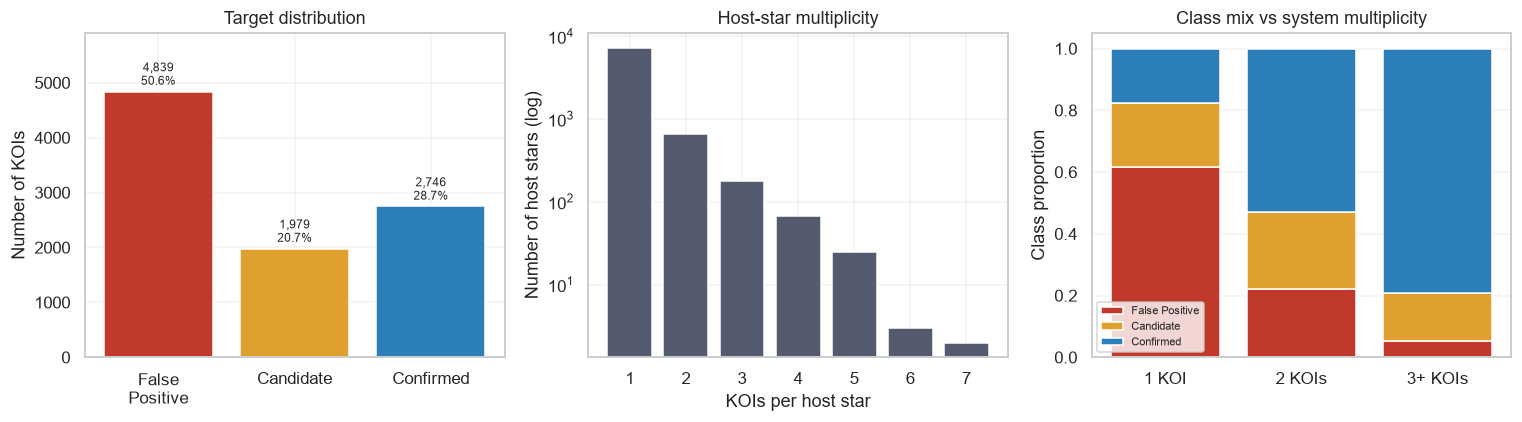

Class proportion by host-star multiplicity:
koi_disposition  FALSE POSITIVE  CANDIDATE  CONFIRMED
bucket                                               
1 KOI                      61.8       20.6       17.6
2 KOIs                     22.2       24.7       53.0
3+ KOIs                     5.4       15.5       79.1


In [8]:
# ---------------------------------------------------------------------------
# Section 8a - Target distribution and multiplicity structure
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

order = ["FALSE POSITIVE", "CANDIDATE", "CONFIRMED"]
colors = ["#c0392b", "#e0a030", "#2c7fb8"]

counts = koi_raw[TARGET_COL].value_counts().reindex(order)
axes[0].bar(range(3), counts.values, color=colors)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(["False\nPositive", "Candidate", "Confirmed"])
axes[0].set_ylabel("Number of KOIs")
axes[0].set_title("Target distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 60, f"{v:,}\n{100 * v / counts.sum():.1f}%",
                 ha="center", va="bottom", fontsize=8)
axes[0].set_ylim(0, counts.max() * 1.22)

koi_per_star = koi_raw[GROUP_COL].value_counts()
mult = koi_per_star.value_counts().sort_index()
axes[1].bar(mult.index, mult.values, color="#555b6e")
axes[1].set_yscale("log")
axes[1].set_xlabel("KOIs per host star")
axes[1].set_ylabel("Number of host stars (log)")
axes[1].set_title("Host-star multiplicity")

# Class composition as a function of multiplicity - motivates koi_count as a feature.
tmp = koi_raw.assign(n_koi=koi_raw[GROUP_COL].map(koi_per_star))
tmp["bucket"] = np.where(tmp["n_koi"] == 1, "1 KOI",
                  np.where(tmp["n_koi"] == 2, "2 KOIs", "3+ KOIs"))
comp = (pd.crosstab(tmp["bucket"], tmp[TARGET_COL], normalize="index")
          .reindex(["1 KOI", "2 KOIs", "3+ KOIs"])[order])
bottom = np.zeros(len(comp))
for cls, col in zip(order, colors):
    axes[2].bar(comp.index, comp[cls].values, bottom=bottom, color=col,
                label=cls.title())
    bottom += comp[cls].values
axes[2].set_ylabel("Class proportion")
axes[2].set_title("Class mix vs system multiplicity")
axes[2].legend(fontsize=7, loc="lower left")
axes[2].grid(axis="x", visible=False)

plt.savefig(OUTPUT_DIR / "fig01_target_and_multiplicity.png", bbox_inches="tight")
plt.show()

print("Class proportion by host-star multiplicity:")
print((comp * 100).round(1).to_string())


**Interpretation.** Three things follow from this figure.

*Left panel.* The classes are imbalanced but not severely so — roughly 51 / 21 / 29 percent. This is
a regime where class weighting is worth testing but where aggressive resampling is unlikely to be
necessary. It also means plain accuracy has a floor of about 0.51 from the majority class alone,
which is why balanced accuracy and macro-F1 are tracked throughout.

*Centre panel.* Most host stars carry a single object of interest, but a long tail carries up to
seven. Those rows share identical stellar parameters. Under a random row-level split, a model can see
a star's parameters in training and be asked about a sibling object of the same star in test — an
optimistic evaluation. Section 11 handles this.

*Right panel.* The class mix shifts sharply with multiplicity: systems with three or more objects are
dominated by confirmed planets, while single-object systems carry most of the false positives. This
is the multiplicity boost — the probability of several independent false positives around one star is
low, so multiplicity is genuine evidence for planethood. It justifies keeping `koi_count` as a
feature and confirms it is not leakage: the number of detections around a star is known from the
search, before any disposition exists.


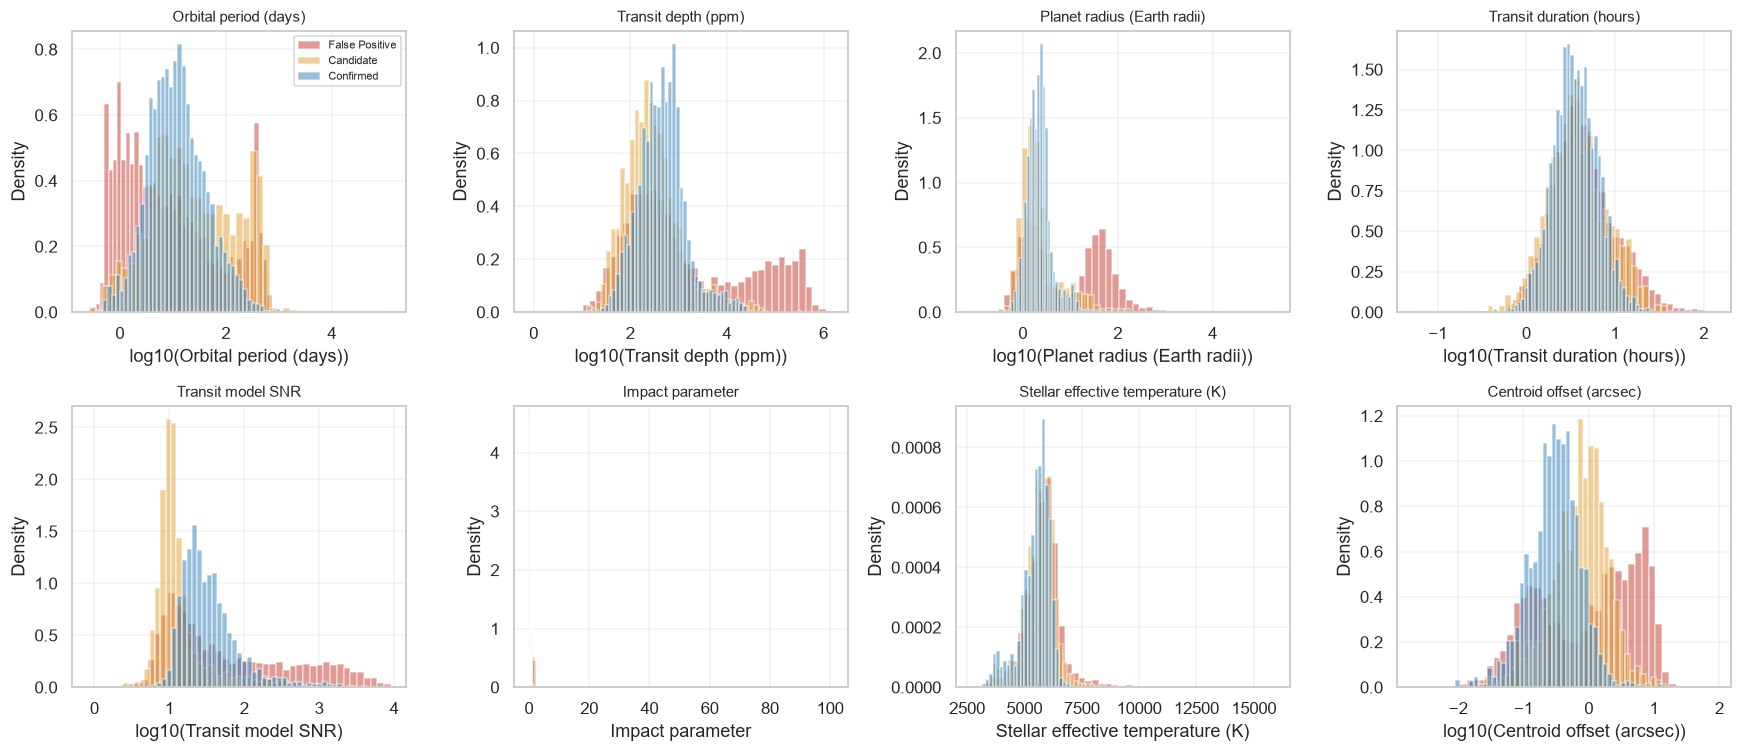

Skewness of the raw (unlogged) features - motivates log transforms
                skewness       min    median          max
koi_period        96.459     0.242     9.753   129995.778
koi_depth          5.261     0.000   421.100  1541400.000
koi_prad          52.119     0.080     2.390   200346.000
koi_duration       5.929     0.052     3.793      138.540
koi_model_snr      5.307     0.000    23.000     9054.700
koi_impact        23.506     0.000     0.537      100.806
koi_steff          0.750  2661.000  5767.000    15896.000
koi_dikco_msky     5.555     0.000     0.583       89.600


In [9]:
# ---------------------------------------------------------------------------
# Section 8b - Distributions of key physical features by class
# ---------------------------------------------------------------------------
eda_features = [
    ("koi_period",     "Orbital period (days)",              True),
    ("koi_depth",      "Transit depth (ppm)",                True),
    ("koi_prad",       "Planet radius (Earth radii)",        True),
    ("koi_duration",   "Transit duration (hours)",           True),
    ("koi_model_snr",  "Transit model SNR",                  True),
    ("koi_impact",     "Impact parameter",                   False),
    ("koi_steff",      "Stellar effective temperature (K)",  False),
    ("koi_dikco_msky", "Centroid offset (arcsec)",           True),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (col, label, use_log) in zip(axes.ravel(), eda_features):
    if col not in koi_raw.columns:
        ax.set_visible(False)
        continue
    for cls, colr in zip(order, colors):
        vals = koi_raw.loc[koi_raw[TARGET_COL] == cls, col].dropna()
        if use_log:
            vals = vals[vals > 0]
            vals = np.log10(vals)
        if len(vals) < 10:
            continue
        ax.hist(vals, bins=45, alpha=0.5, color=colr, label=cls.title(), density=True)
    ax.set_xlabel(f"log10({label})" if use_log else label)
    ax.set_ylabel("Density")
    ax.set_title(label, fontsize=10)
axes.ravel()[0].legend(fontsize=7)
plt.savefig(OUTPUT_DIR / "fig02_feature_distributions.png", bbox_inches="tight")
plt.show()

print("Skewness of the raw (unlogged) features - motivates log transforms")
skew_tbl = pd.DataFrame({
    "skewness": [koi_raw[c].skew() for c, _, _ in eda_features if c in koi_raw.columns],
    "min": [koi_raw[c].min() for c, _, _ in eda_features if c in koi_raw.columns],
    "median": [koi_raw[c].median() for c, _, _ in eda_features if c in koi_raw.columns],
    "max": [koi_raw[c].max() for c, _, _ in eda_features if c in koi_raw.columns],
}, index=[c for c, _, _ in eda_features if c in koi_raw.columns])
print(skew_tbl.round(3).to_string())


**Interpretation.** The class-conditional distributions confirm the physical expectations set out
in Section 7, and each one carries a modelling consequence.

* **Transit depth and planet radius** separate false positives most cleanly. False positives extend
  to depths and inferred radii far beyond anything physically achievable for a planet — the tail
  above roughly 25 Earth radii is essentially pure stellar-companion contamination.
* **Centroid offset** is strongly bimodal by class. Objects whose photocentre shifts during transit
  are overwhelmingly false positives, exactly as the background-eclipsing-binary picture predicts.
  This feature does not exist in the production feature set at all.
* **Transit model SNR** shows confirmed planets shifted to higher significance, which is partly
  physical and partly a selection effect: high-SNR detections are prioritised for follow-up and are
  therefore more likely to have been resolved.
* **Candidates sit between the two other classes on nearly every axis.** This is the central
  difficulty of the problem and it is not a modelling artefact — it is what "candidate" means.
* **Every extensive quantity is heavily right-skewed** (skewness in the tens to hundreds), spanning
  several orders of magnitude. Tree ensembles are invariant to monotone transforms so this does not
  affect them, but it matters a great deal for the linear baseline, which is why log transforms are
  applied in Section 10.


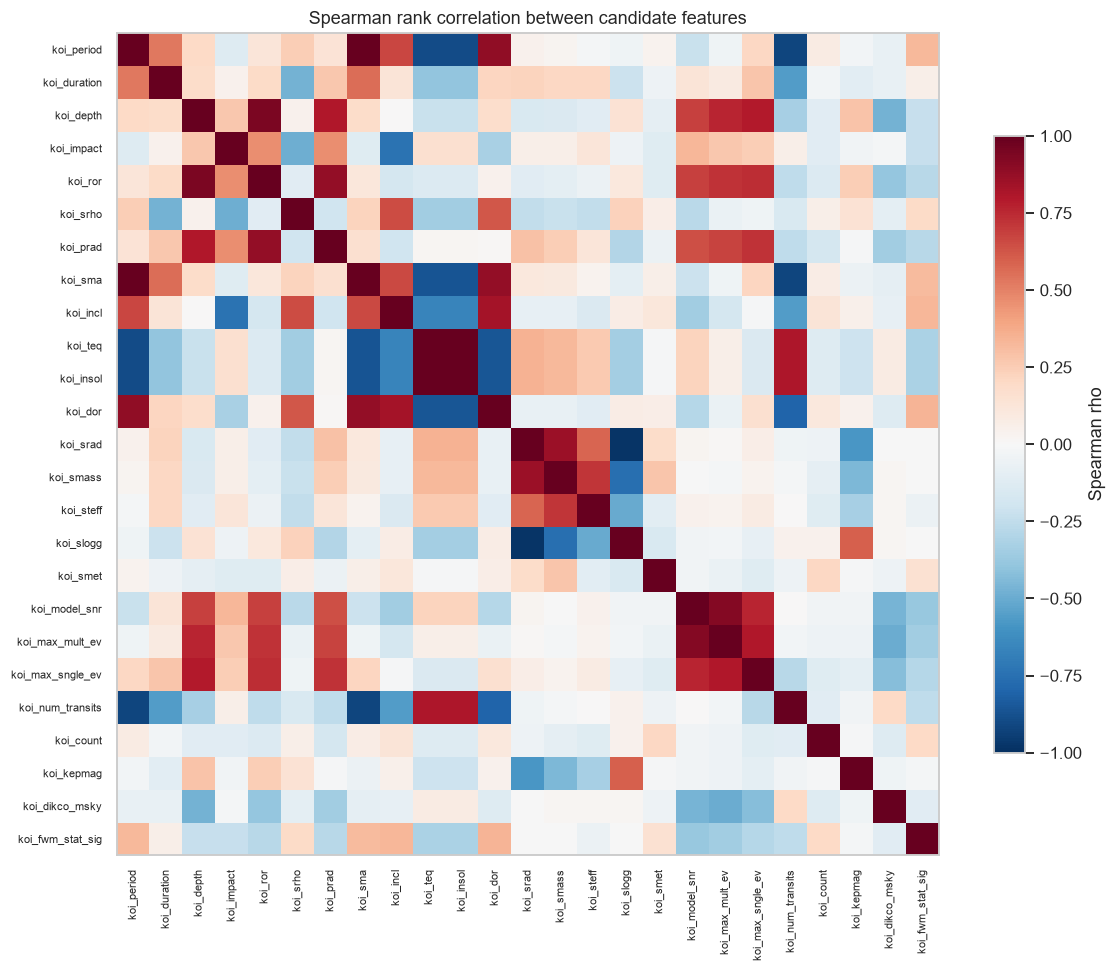

Most strongly correlated feature pairs (|rho| >= 0.8)
      level_0          level_1    rho  abs_rho
      koi_teq        koi_insol  1.000    1.000
   koi_period          koi_sma  0.996    0.996
     koi_srad        koi_slogg -0.980    0.980
    koi_depth          koi_ror  0.938    0.938
   koi_period koi_num_transits -0.922    0.922
      koi_sma koi_num_transits -0.920    0.920
koi_model_snr  koi_max_mult_ev  0.916    0.916
   koi_period          koi_teq -0.896    0.896
   koi_period        koi_insol -0.896    0.896
   koi_period          koi_dor  0.889    0.889
      koi_ror         koi_prad  0.880    0.880
      koi_sma          koi_dor  0.877    0.877
      koi_sma          koi_teq -0.862    0.862
      koi_sma        koi_insol -0.862    0.862
      koi_teq          koi_dor -0.858    0.858


In [10]:
# ---------------------------------------------------------------------------
# Section 8c - Correlation structure among candidate numeric features
# ---------------------------------------------------------------------------
corr_cols = [c for c in [
    "koi_period", "koi_duration", "koi_depth", "koi_impact", "koi_ror", "koi_srho",
    "koi_prad", "koi_sma", "koi_incl", "koi_teq", "koi_insol", "koi_dor",
    "koi_srad", "koi_smass", "koi_steff", "koi_slogg", "koi_smet",
    "koi_model_snr", "koi_max_mult_ev", "koi_max_sngle_ev", "koi_num_transits",
    "koi_count", "koi_kepmag", "koi_dikco_msky", "koi_fwm_stat_sig",
] if c in koi_raw.columns]

corr = koi_raw[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=7)
ax.set_title("Spearman rank correlation between candidate features")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="Spearman rho")
plt.savefig(OUTPUT_DIR / "fig03_correlation.png", bbox_inches="tight")
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().rename("rho").reset_index())
pairs["abs_rho"] = pairs["rho"].abs()
print("Most strongly correlated feature pairs (|rho| >= 0.8)")
print(pairs[pairs["abs_rho"] >= 0.8]
      .sort_values("abs_rho", ascending=False)
      .head(15).to_string(index=False, float_format=lambda v: f"{v:.3f}"))


**Interpretation.** The correlation structure is exactly what the physics implies, and it is
strong: `koi_prad` is a deterministic function of `koi_ror` and `koi_srad`; `koi_sma`, `koi_dor` and
`koi_period` are tied by Kepler's third law; `koi_teq` and `koi_insol` are both functions of stellar
temperature and orbital distance; the detection statistics `koi_model_snr` and `koi_max_mult_ev`
measure closely related things.

The decision this drives is **not** to prune correlated features. Tree ensembles handle collinearity
without instability — it dilutes individual importance scores but does not degrade predictions. The
consequence is confined to interpretation: Section 20 uses permutation importance alongside built-in
importance precisely because correlated groups split their credit arbitrarily in impurity-based
rankings. For the logistic-regression baseline, where collinearity genuinely destabilises
coefficients, regularisation and standardisation are applied instead.


## 9. Data quality

Before feature selection, the table is checked for the failure modes that silently corrupt a model:
columns with no information, values outside physical bounds, infinities produced by ratio features,
and inconsistent categorical encodings.


In [11]:
# ---------------------------------------------------------------------------
# Section 9 - Data quality diagnostics
# ---------------------------------------------------------------------------
numeric_all = koi_raw.select_dtypes(include=[np.number])

empty_cols = [c for c in koi_raw.columns if koi_raw[c].isna().all()]
constant_cols = [c for c in koi_raw.columns
                 if c not in empty_cols and koi_raw[c].nunique(dropna=True) <= 1]

# "Near constant": a single value accounts for >99.5% of non-missing entries.
near_constant = []
for c in numeric_all.columns:
    s = numeric_all[c].dropna()
    if len(s) and c not in constant_cols and s.value_counts(normalize=True).iloc[0] > 0.995:
        near_constant.append((c, float(s.value_counts(normalize=True).iloc[0]),
                              float(s.value_counts().index[0])))

print(f"Entirely empty columns   : {len(empty_cols)} -> {empty_cols}")
print(f"Constant columns         : {len(constant_cols)} -> {constant_cols}")
print(f"Near-constant columns    : {len(near_constant)}")
for c, frac, val in near_constant:
    print(f"    {c:<24} {frac * 100:.2f}% equal to {val}")

print(f"\nInfinite values present  : "
      f"{int(np.isinf(numeric_all.to_numpy(dtype='float64', na_value=np.nan)).sum())}")

print("\nPhysical plausibility checks")
checks = [
    ("koi_period",   "orbital period <= 0",           lambda s: s <= 0),
    ("koi_duration", "transit duration <= 0",         lambda s: s <= 0),
    ("koi_depth",    "transit depth <= 0",            lambda s: s <= 0),
    ("koi_prad",     "planet radius > 25 R_Earth",    lambda s: s > 25),
    ("koi_impact",   "impact parameter > 1 (grazing)", lambda s: s > 1),
    ("koi_srad",     "stellar radius <= 0",           lambda s: s <= 0),
    ("koi_steff",    "stellar Teff outside 2000-12000 K",
                     lambda s: (s < 2000) | (s > 12000)),
]
for col, desc, test in checks:
    if col not in koi_raw.columns:
        continue
    s = koi_raw[col].dropna()
    n = int(test(s).sum())
    print(f"  {desc:<38} {n:>5} rows ({100 * n / max(len(s), 1):.2f}%)")

print("\nClass composition of the implausible-radius rows (koi_prad > 25 R_Earth)")
big = koi_raw[koi_raw["koi_prad"] > 25]
print(big[TARGET_COL].value_counts(normalize=True).round(3).to_string())
print(f"  n = {len(big):,}")

print("\nCategorical column consistency")
for c in koi_raw.select_dtypes(include=["object"]).columns:
    nun = koi_raw[c].nunique(dropna=True)
    if nun <= 12:
        print(f"  {c:<22} {nun:>3} levels -> {sorted(map(str, koi_raw[c].dropna().unique()))[:8]}")


Entirely empty columns   : 19 -> ['koi_eccen_err1', 'koi_eccen_err2', 'koi_longp', 'koi_longp_err1', 'koi_longp_err2', 'koi_ingress', 'koi_ingress_err1', 'koi_ingress_err2', 'koi_sma_err1', 'koi_sma_err2', 'koi_incl_err1', 'koi_incl_err2', 'koi_teq_err1', 'koi_teq_err2', 'koi_model_dof', 'koi_model_chisq', 'koi_sage', 'koi_sage_err1', 'koi_sage_err2']
Constant columns         : 8 -> ['koi_vet_stat', 'koi_vet_date', 'koi_disp_prov', 'koi_eccen', 'koi_limbdark_mod', 'koi_ldm_coeff4', 'koi_ldm_coeff3', 'koi_trans_mod']
Near-constant columns    : 0



Infinite values present  : 0

Physical plausibility checks
  orbital period <= 0                        0 rows (0.00%)
  transit duration <= 0                      0 rows (0.00%)
  transit depth <= 0                         1 rows (0.01%)
  planet radius > 25 R_Earth              1880 rows (20.43%)
  impact parameter > 1 (grazing)          1308 rows (14.22%)
  stellar radius <= 0                        0 rows (0.00%)
  stellar Teff outside 2000-12000 K          1 rows (0.01%)

Class composition of the implausible-radius rows (koi_prad > 25 R_Earth)
koi_disposition
FALSE POSITIVE    0.953
CANDIDATE         0.041
CONFIRMED         0.006
  n = 1,880

Categorical column consistency
  koi_disposition          3 levels -> ['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE']
  koi_vet_stat             1 levels -> ['Done']
  koi_vet_date             1 levels -> ['2018-08-16']
  koi_pdisposition         2 levels -> ['CANDIDATE', 'FALSE POSITIVE']
  koi_disp_prov            1 levels -> ['q1_q17_dr25_su

**Interpretation and treatment.**

* **Empty and constant columns** carry zero information and are removed. They cost nothing to drop
  and would otherwise waste split candidates and clutter importance rankings.
* **Grazing geometries (`koi_impact > 1`)** are *not* errors. An impact parameter above 1 means the
  transit chord misses the stellar disc under the fitted model, which happens for genuine grazing
  eclipses and for poorly constrained fits. Both are informative about disposition, so these rows are
  kept unchanged.
* **Implausibly large radii (`koi_prad > 25 R⊕`)** are similarly not errors to be cleaned. As the
  class breakdown above shows, they are overwhelmingly false positives — objects the transit fit
  sized as stellar rather than planetary. Deleting or clipping them would remove one of the strongest
  legitimate signals in the dataset. They are retained.
* **Missing values are retained as missing.** This is the sharpest departure from the production
  pipeline, which drops any incomplete row. Here, HistGradientBoosting, XGBoost and LightGBM all
  route `NaN` natively, and explicit missingness-indicator features are added in Section 10 so the
  models can use *the fact that a measurement is absent* as evidence. Section 9.2 shows that
  missingness is far from random with respect to the target, which makes this doubly important — and
  also raises a leakage concern handled immediately below.
* **No infinities** are present in the source table. Ratio features created in Section 10 use an
  epsilon-guarded denominator, following the convention already used in
  `training/feature_engineering.py`, and are re-checked after construction.


## 10. Leakage analysis

This is the most important section of the notebook. The KOI table contains columns produced *by* the
disposition process, and a model given those columns will reach very high accuracy while learning
nothing about exoplanets. Two distinct kinds of leakage are present, and the second is subtle enough
that it is easy to miss.

### 10.1 Direct leakage — columns that encode the answer

| Column | Why it must be excluded |
|---|---|
| `koi_disposition` | The target itself. |
| `koi_pdisposition` | The Kepler pipeline's *own automated disposition*. Using it means predicting a label from another classifier's prediction of the same label. |
| `koi_score` | A disposition confidence score produced by the Robovetter *as part of assigning the disposition*. |
| `koi_fpflag_nt`, `koi_fpflag_ss`, `koi_fpflag_co`, `koi_fpflag_ec` | The four false-positive flags. An object is labelled `FALSE POSITIVE` largely *because* one of these is set. These do not predict the label; they define it. |
| `koi_disp_prov`, `koi_comment` | Provenance and free-text notes describing how the disposition was reached. |
| `koi_vet_stat`, `koi_vet_date` | Vetting status and date — meaningful only after vetting occurred. |
| `kepler_name` | **The most seductive leak in the table.** Only confirmed planets receive a Kepler designation. This column is non-null if and only if the class is `CONFIRMED`. |
| `kepoi_name`, `kepid`, `rowid` | Identifiers. `kepid` is retained separately as the grouping key but never as a feature. |
| `koi_datalink_dvr`, `koi_datalink_dvs`, `koi_quarters`, `koi_tce_delivname`, `koi_parm_prov`, `koi_sparprov`, `koi_limbdark_mod`, `koi_trans_mod`, `koi_fittype` | Bookkeeping, provenance and model-name strings. Not physical measurements; several correlate with processing batch, which correlates with disposition. |

### 10.2 Indirect leakage — follow-up-contaminated uncertainties

The second kind is harder to see and does not appear on any standard leakage checklist for this
dataset.

Confirming a planet requires **follow-up observations**: high-resolution spectroscopy of the host
star, adaptive-optics imaging, sometimes radial-velocity monitoring. Those observations do not only
confirm the planet — they also **re-characterise the host star** to much higher precision. The
archive then updates that star's stellar parameters and, critically, their **uncertainties**.

The consequence is that stellar-parameter error columns (`koi_steff_err*`, `koi_srad_err*`,
`koi_smass_err*`, `koi_slogg_err*`, `koi_smet_err*`) carry a signature of *whether follow-up
happened*, which is nearly the same thing as *whether the object was confirmed*. Any derived
quantity computed from stellar parameters inherits the contamination: `koi_prad_err` propagates
`koi_srad_err`, and `koi_sma_err`, `koi_teq_err`, `koi_insol_err`, `koi_dor_err` likewise.

The evidence for this is measured below, and it is unambiguous — both in the magnitude of the
uncertainties and, even more starkly, in their *missingness rate* by class.

### 10.3 What is deliberately kept, and why it is not leakage

The Data Validation diagnostics from Section 7.3 (`koi_model_snr`, `koi_max_mult_ev`,
`koi_bin_oedp_sig`, the centroid-offset columns, `koi_count`, `koi_num_transits`) are **retained**.
The distinction is temporal and procedural:

* These are computed automatically by the Kepler DV pipeline from photometry and pixel data, and are
  available for every threshold crossing event **before any human or Robovetter disposition exists**.
* They are the *inputs* a vetter examines, not the *outputs* the vetter produces. The false-positive
  flags are the outputs, and those are excluded.
* They are exactly the information an operational triage system would legitimately have for a new
  detection — which is the deployment scenario Exoplanetarium targets.

This distinction is defensible but it is a judgement call, so it is **tested rather than asserted**:
Section 10.5 runs an ablation with the DV diagnostics removed and reports what the model achieves
without them.


In [12]:
# ---------------------------------------------------------------------------
# Section 10a - Direct leakage: demonstrate the failure, then exclude it
# ---------------------------------------------------------------------------
from sklearn.model_selection import train_test_split as _tts

y_all = koi_raw[TARGET_COL].map(LABEL_MAP).astype(int)

print("Evidence for `kepler_name` being a perfect class indicator:")
has_name = koi_raw["kepler_name"].notna()
print(pd.crosstab(koi_raw[TARGET_COL], has_name.rename("has_kepler_name")).to_string())

print("\nEvidence for the false-positive flags defining the label:")
flag_cols = [c for c in ["koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec"]
             if c in koi_raw.columns]
any_flag = koi_raw[flag_cols].fillna(0).sum(axis=1) > 0
print(pd.crosstab(koi_raw[TARGET_COL], any_flag.rename("any_fp_flag_set"),
                  normalize="index").round(3).to_string())

print("\nEvidence for `koi_pdisposition` being another model's answer:")
print(pd.crosstab(koi_raw[TARGET_COL], koi_raw["koi_pdisposition"]).to_string())

# Quantify the inflation a leaky model would enjoy.
leaky_cols = flag_cols + ["koi_score", "koi_pdisposition"]
leaky_frame = koi_raw[leaky_cols].copy()
leaky_frame["koi_pdisposition"] = leaky_frame["koi_pdisposition"].map(
    {"CANDIDATE": 1, "FALSE POSITIVE": 0}).astype("float64")
leaky_frame["has_kepler_name"] = has_name.astype(int)

Xl_tr, Xl_te, yl_tr, yl_te = _tts(leaky_frame, y_all, test_size=0.2,
                                  stratify=y_all, random_state=RANDOM_STATE)
leak_demo = HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE)
leak_demo.fit(Xl_tr, yl_tr)
LEAKY_ACCURACY = accuracy_score(yl_te, leak_demo.predict(Xl_te))

print(f"\n{'=' * 74}")
print(f"A model using ONLY the {leaky_frame.shape[1]} leakage columns reaches "
      f"accuracy = {LEAKY_ACCURACY:.4f}")
print("This number is reported to be rejected, not celebrated. It is what a")
print("notebook that skipped this section would proudly present as its result.")
print("Every column used above is excluded from all models that follow.")
print("=" * 74)


Evidence for `kepler_name` being a perfect class indicator:
has_kepler_name  False  True 
koi_disposition              
CANDIDATE         1979      0
CONFIRMED            1   2745
FALSE POSITIVE    4837      2

Evidence for the false-positive flags defining the label:
any_fp_flag_set  False  True 
koi_disposition              
CANDIDATE        0.998  0.002
CONFIRMED        0.993  0.007
FALSE POSITIVE   0.020  0.980

Evidence for `koi_pdisposition` being another model's answer:
koi_pdisposition  CANDIDATE  FALSE POSITIVE
koi_disposition                            
CANDIDATE              1979               0
CONFIRMED              2737               9
FALSE POSITIVE            1            4838



A model using ONLY the 7 leakage columns reaches accuracy = 0.9995
This number is reported to be rejected, not celebrated. It is what a
notebook that skipped this section would proudly present as its result.
Every column used above is excluded from all models that follow.


Stellar-parameter uncertainty columns, broken down by class
        column  missing% FP  missing% CAND  missing% CONF  median |err| FP  median |err| CAND  median |err| CONF
koi_steff_err1        7.357          5.558          0.073          165.000            156.000            108.000
koi_steff_err2        7.398          5.558          0.546          179.000            159.000            114.000
koi_slogg_err1        7.357          5.558          0.073            0.075              0.067              0.063
koi_slogg_err2        7.357          5.558          0.073            0.168              0.136              0.105
 koi_smet_err1        5.745          5.407          0.073            0.260              0.250              0.150
 koi_smet_err2        5.745          5.407          0.073            0.300              0.300              0.150
 koi_srad_err1        7.357          5.558          0.073            0.305              0.267              0.161
 koi_srad_err2        7.357         

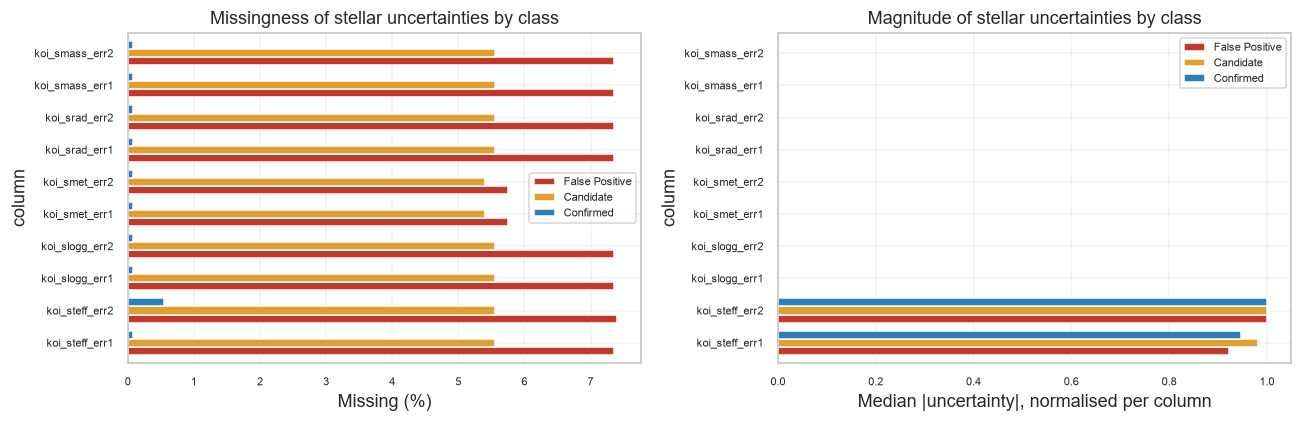

In [13]:
# ---------------------------------------------------------------------------
# Section 10b - Indirect leakage: follow-up contamination of stellar uncertainties
# ---------------------------------------------------------------------------
stellar_err_cols = [c for c in koi_raw.columns
                    if re.match(r"koi_(steff|slogg|smet|srad|smass)_err[12]$", c)]

rows = []
for c in stellar_err_cols:
    grp = koi_raw.groupby(TARGET_COL)[c]
    rows.append({
        "column": c,
        "missing% FP":   100 * grp.apply(lambda s: s.isna().mean())["FALSE POSITIVE"],
        "missing% CAND": 100 * grp.apply(lambda s: s.isna().mean())["CANDIDATE"],
        "missing% CONF": 100 * grp.apply(lambda s: s.isna().mean())["CONFIRMED"],
        "median |err| FP":   abs(grp.median()["FALSE POSITIVE"]),
        "median |err| CAND": abs(grp.median()["CANDIDATE"]),
        "median |err| CONF": abs(grp.median()["CONFIRMED"]),
    })
leak_evidence = pd.DataFrame(rows)
print("Stellar-parameter uncertainty columns, broken down by class")
print(leak_evidence.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("\nThe pattern is systematic and in the same direction for every column:")
print("  * CONFIRMED objects are almost never missing stellar uncertainties,")
print("    while CANDIDATE and FALSE POSITIVE objects are missing them several")
print("    percent of the time.")
print("  * CONFIRMED objects have systematically SMALLER uncertainties.")
print("Both follow from confirmed planets having received dedicated host-star")
print("characterisation as part of the confirmation process. That is information")
print("created AFTER the disposition, so it cannot be used to predict it.")

# Provenance tells the same story from a different angle.
print("\nStellar-parameter provenance by class (proportion within class):")
print((pd.crosstab(koi_raw[TARGET_COL], koi_raw["koi_sparprov"], normalize="index")
       * 100).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
miss_plot = leak_evidence.set_index("column")[["missing% FP", "missing% CAND", "missing% CONF"]]
miss_plot.plot(kind="barh", ax=axes[0], color=colors, width=0.75)
axes[0].set_xlabel("Missing (%)")
axes[0].set_title("Missingness of stellar uncertainties by class")
axes[0].legend(["False Positive", "Candidate", "Confirmed"], fontsize=7)
axes[0].tick_params(labelsize=7)

med_plot = leak_evidence.set_index("column")[
    ["median |err| FP", "median |err| CAND", "median |err| CONF"]]
(med_plot / med_plot.max(axis=0)).plot(kind="barh", ax=axes[1], color=colors, width=0.75)
axes[1].set_xlabel("Median |uncertainty|, normalised per column")
axes[1].set_title("Magnitude of stellar uncertainties by class")
axes[1].legend(["False Positive", "Candidate", "Confirmed"], fontsize=7)
axes[1].tick_params(labelsize=7)
plt.savefig(OUTPUT_DIR / "fig04_indirect_leakage.png", bbox_inches="tight")
plt.show()


In [14]:
# ---------------------------------------------------------------------------
# Section 10c - Construct the final leakage-safe feature set
# ---------------------------------------------------------------------------
DIRECT_LEAKAGE = [
    TARGET_COL, "koi_pdisposition", "koi_score",
    "koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec",
    "koi_disp_prov", "koi_comment", "koi_vet_stat", "koi_vet_date",
    "kepler_name", "kepoi_name", "kepid", "rowid",
    "koi_datalink_dvr", "koi_datalink_dvs", "koi_quarters", "koi_tce_delivname",
    "koi_parm_prov", "koi_sparprov", "koi_limbdark_mod", "koi_trans_mod", "koi_fittype",
]

# Every uncertainty column on a stellar parameter, or on a quantity derived from one.
INDIRECT_LEAKAGE = sorted(
    c for c in koi_raw.columns
    if re.match(r"koi_(steff|slogg|smet|srad|smass|sage|prad|sma|teq|insol|dor)_err[12]?$", c)
)

# Data Validation diagnostics: legitimate, but flagged so they can be ablated.
DV_DIAGNOSTICS = [c for c in [
    "koi_model_snr", "koi_max_sngle_ev", "koi_max_mult_ev", "koi_num_transits",
    "koi_count", "koi_bin_oedp_sig", "koi_fwm_stat_sig",
    "koi_model_chisq", "koi_model_dof",
] if c in koi_raw.columns] + [c for c in koi_raw.columns
                              if c.startswith(("koi_fwm_", "koi_dicco_", "koi_dikco_"))]
DV_DIAGNOSTICS = sorted(set(DV_DIAGNOSTICS))

excluded = set(DIRECT_LEAKAGE) | set(INDIRECT_LEAKAGE)
candidate_cols = [c for c in koi_raw.columns if c not in excluded]

# Keep numeric columns only; the surviving object columns are all provenance strings
# already listed above.
feature_frame = koi_raw[candidate_cols].select_dtypes(include=[np.number])

# Drop empty / constant columns identified in Section 9.
drop_uninformative = [c for c in feature_frame.columns
                      if feature_frame[c].isna().all() or feature_frame[c].nunique(dropna=True) <= 1]
feature_frame = feature_frame.drop(columns=drop_uninformative)

BASE_FEATURES = list(feature_frame.columns)

print(f"Columns in the raw KOI table                 : {koi_raw.shape[1]}")
print(f"  removed - direct leakage                   : "
      f"{len([c for c in DIRECT_LEAKAGE if c in koi_raw.columns])}")
print(f"  removed - indirect (follow-up) leakage     : {len(INDIRECT_LEAKAGE)}")
print(f"  removed - non-numeric / provenance         : "
      f"{len(candidate_cols) - feature_frame.shape[1] - len(drop_uninformative)}")
print(f"  removed - empty or constant                : {len(drop_uninformative)}")
print(f"Leakage-safe base features retained          : {len(BASE_FEATURES)}")

print(f"\nIndirect-leakage columns removed ({len(INDIRECT_LEAKAGE)}):")
print("  " + ", ".join(INDIRECT_LEAKAGE))
print(f"\nData Validation diagnostics retained ({len(DV_DIAGNOSTICS)}):")
print("  " + ", ".join(DV_DIAGNOSTICS))
print(f"\nUninformative columns removed: {drop_uninformative}")


Columns in the raw KOI table                 : 141
  removed - direct leakage                   : 24
  removed - indirect (follow-up) leakage     : 22
  removed - non-numeric / provenance         : 0
  removed - empty or constant                : 16
Leakage-safe base features retained          : 79

Indirect-leakage columns removed (22):
  koi_dor_err1, koi_dor_err2, koi_insol_err1, koi_insol_err2, koi_prad_err1, koi_prad_err2, koi_sage_err1, koi_sage_err2, koi_slogg_err1, koi_slogg_err2, koi_sma_err1, koi_sma_err2, koi_smass_err1, koi_smass_err2, koi_smet_err1, koi_smet_err2, koi_srad_err1, koi_srad_err2, koi_steff_err1, koi_steff_err2, koi_teq_err1, koi_teq_err2

Data Validation diagnostics retained (33):
  koi_bin_oedp_sig, koi_count, koi_dicco_mdec, koi_dicco_mdec_err, koi_dicco_mra, koi_dicco_mra_err, koi_dicco_msky, koi_dicco_msky_err, koi_dikco_mdec, koi_dikco_mdec_err, koi_dikco_mra, koi_dikco_mra_err, koi_dikco_msky, koi_dikco_msky_err, koi_fwm_pdeco, koi_fwm_pdeco_err, koi_fw

## 11. Feature engineering

Two families of engineered features are added, each with an explicit rationale. Nothing is added
speculatively; Section 20 checks whether the additions earn their place.

**Family 1 — the production pipeline's derived features.** All six ratios from
`training/feature_engineering.py` are reproduced exactly, including its epsilon-guarded denominators.
Reusing them keeps the research directly comparable with the deployed system and tests whether the
project's existing domain intuition holds up:

* `transit_snr` = depth / duration — a crude per-unit-time signal strength.
* `planet_star_ratio` = planet radius / stellar radius — dimensionless size ratio.
* `depth_radius_ratio` = depth / planet radius — consistency between observed depth and inferred size.
* `impact_factor` = impact parameter / stellar radius.
* `scaled_teq` = equilibrium temperature / stellar temperature.
* `log_orbital_period` = log1p(period).

**Family 2 — physically motivated additions.**

* **Log transforms** of the strongly right-skewed extensive quantities (period, depth, planet radius,
  insolation, semi-major axis, model SNR, multiple-event statistic). Tree models are invariant to
  these, but the logistic-regression baseline is not, and a baseline crippled by scale would make the
  boosted models look better than they are. Comparing against a *fairly configured* baseline is the
  point of having one.
* **Odd-even and grazing indicators.** `is_grazing` (impact parameter > 0.9) and
  `implausible_radius` (planet radius > 25 R⊕) encode two textbook eclipsing-binary signatures as
  explicit binary features, so a shallow tree can use them in one split.
* **Centroid-offset significance.** The offset divided by its own uncertainty is the quantity that
  actually matters — a 1-arcsecond offset measured to 0.1 arcsecond is decisive, the same offset
  measured to 3 arcseconds is noise.
* **Single-to-multiple event ratio** (`koi_max_sngle_ev / koi_max_mult_ev`). A value near 1 means one
  event dominates the detection, which indicates a systematic rather than a repeating transit.
* **Duration-period consistency.** For a central transit of a Sun-like star, duration scales roughly
  as period^(1/3). The ratio of observed duration to that expectation flags geometrically
  inconsistent fits.
* **Missingness indicators** for the columns whose absence is informative *and not
  follow-up-contaminated*. Section 9 established that missingness is non-random; the leakage analysis
  established that stellar-uncertainty missingness is contaminated. Indicators are therefore built
  only for transit-fit and DV columns, never for stellar-parameter columns.

**What is deliberately not done.** No target encoding, no aggregation over host stars, and no
statistic computed across the full dataset before splitting — each of those would leak either the
target or test-set information into training.


In [15]:
# ---------------------------------------------------------------------------
# Section 11 - Feature engineering
# ---------------------------------------------------------------------------
# NOTE ON LEAKAGE SAFETY: every transformation below is row-wise. None uses the
# target, and none uses any statistic computed across rows (no means, no medians,
# no target encoding). It is therefore safe to apply before splitting - the
# operation on a given row is identical whether or not the rest of the data exists.
# Statistics that DO depend on other rows (imputation medians, scaler parameters)
# are fitted inside cross-validation pipelines only.

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # --- Family 1: the six derived features from the production pipeline ------
    if {"koi_depth", "koi_duration"} <= set(out.columns):
        out["transit_snr"] = out["koi_depth"] / (out["koi_duration"] + EPSILON)
    if {"koi_prad", "koi_srad"} <= set(out.columns):
        out["planet_star_ratio"] = out["koi_prad"] / (out["koi_srad"] + EPSILON)
    if {"koi_depth", "koi_prad"} <= set(out.columns):
        out["depth_radius_ratio"] = out["koi_depth"] / (out["koi_prad"] + EPSILON)
    if {"koi_impact", "koi_srad"} <= set(out.columns):
        out["impact_factor"] = out["koi_impact"] / (out["koi_srad"] + EPSILON)
    if {"koi_teq", "koi_steff"} <= set(out.columns):
        out["scaled_teq"] = out["koi_teq"] / (out["koi_steff"] + EPSILON)
    if "koi_period" in out.columns:
        out["log_orbital_period"] = np.log1p(out["koi_period"])

    # --- Family 2a: log transforms of strongly right-skewed quantities --------
    for col in ["koi_depth", "koi_prad", "koi_insol", "koi_sma",
                "koi_model_snr", "koi_max_mult_ev", "koi_max_sngle_ev"]:
        if col in out.columns:
            out[f"log_{col}"] = np.log1p(out[col].clip(lower=0))

    # --- Family 2b: explicit false-positive signatures ------------------------
    if "koi_impact" in out.columns:
        out["is_grazing"] = (out["koi_impact"] > 0.9).astype("int8")
    if "koi_prad" in out.columns:
        out["implausible_radius"] = (out["koi_prad"] > 25).astype("int8")

    # --- Family 2c: centroid-offset significance ------------------------------
    for base in ["koi_dicco_msky", "koi_dikco_msky"]:
        if {base, base + "_err"} <= set(out.columns):
            out[f"{base}_sig"] = out[base] / (out[base + "_err"].abs() + EPSILON)

    # --- Family 2d: single- vs multiple-event dominance -----------------------
    if {"koi_max_sngle_ev", "koi_max_mult_ev"} <= set(out.columns):
        out["sngle_mult_ev_ratio"] = (out["koi_max_sngle_ev"]
                                      / (out["koi_max_mult_ev"].abs() + EPSILON))

    # --- Family 2e: transit duration / period consistency ---------------------
    if {"koi_duration", "koi_period"} <= set(out.columns):
        expected_duration = out["koi_period"].clip(lower=0) ** (1.0 / 3.0)
        out["duration_period_consistency"] = out["koi_duration"] / (expected_duration + EPSILON)

    # --- Family 2f: missingness indicators (leakage-safe subset only) ---------
    for col in MISSINGNESS_INDICATOR_COLS:
        if col in out.columns:
            out[f"missing_{col}"] = out[col].isna().astype("int8")

    return out


# Missingness indicators are built ONLY for transit-fit and DV columns. Stellar
# parameter missingness was shown in Section 10b to be follow-up contaminated.
MISSINGNESS_INDICATOR_COLS = [c for c in [
    "koi_impact", "koi_duration", "koi_depth", "koi_prad", "koi_teq", "koi_insol",
    "koi_model_snr", "koi_srho", "koi_ror", "koi_dor", "koi_incl",
    "koi_bin_oedp_sig", "koi_dikco_msky", "koi_fwm_stat_sig",
] if c in koi_raw.columns]

X_full = engineer_features(koi_raw[BASE_FEATURES])
y_full = koi_raw[TARGET_COL].map(LABEL_MAP).astype(int)
groups_full = koi_raw[GROUP_COL].to_numpy()

# Guard against infinities introduced by the ratio features.
n_inf = int(np.isinf(X_full.to_numpy(dtype="float64", na_value=np.nan)).sum())
X_full = X_full.replace([np.inf, -np.inf], np.nan)

ENGINEERED = [c for c in X_full.columns if c not in BASE_FEATURES]
print(f"Base leakage-safe features   : {len(BASE_FEATURES)}")
print(f"Engineered features added    : {len(ENGINEERED)}")
print(f"Total feature matrix         : {X_full.shape}")
print(f"Infinities created by ratios : {n_inf} (replaced with NaN)")
print(f"Overall missing rate         : {X_full.isna().mean().mean() * 100:.2f}%")
print()
print("Engineered features:")
for i in range(0, len(ENGINEERED), 3):
    print("  " + "".join(f"{c:<32}" for c in ENGINEERED[i:i + 3]))

# Sanity assertion: no leakage column can have survived into the matrix.
assert not (set(X_full.columns) & (set(DIRECT_LEAKAGE) | set(INDIRECT_LEAKAGE))), \
    "A leakage column survived into the feature matrix"
print("\nLeakage guard passed: no excluded column is present in X_full.")


Base leakage-safe features   : 79
Engineered features added    : 33
Total feature matrix         : (9564, 112)
Infinities created by ratios : 0 (replaced with NaN)
Overall missing rate         : 4.00%

Engineered features:
  transit_snr                     planet_star_ratio               depth_radius_ratio              
  impact_factor                   scaled_teq                      log_orbital_period              
  log_koi_depth                   log_koi_prad                    log_koi_insol                   
  log_koi_sma                     log_koi_model_snr               log_koi_max_mult_ev             
  log_koi_max_sngle_ev            is_grazing                      implausible_radius              
  koi_dicco_msky_sig              koi_dikco_msky_sig              sngle_mult_ev_ratio             
  duration_period_consistency     missing_koi_impact              missing_koi_duration            
  missing_koi_depth               missing_koi_prad                missing_koi_teq   

## 12. Train / validation / test strategy

### 12.1 Why a random row-level split is not defensible here

Section 8a established that 1,350 of the 9,564 KOI rows share a host star with at least one other
row, with up to seven objects around a single star. Rows sharing a host star share **identical values
for every stellar column** — `koi_srad`, `koi_smass`, `koi_steff`, `koi_slogg`, `koi_smet` — and near
identical values for `koi_count`, `koi_kepmag`, `ra` and `dec`.

Under a random split, a model can memorise a specific star's parameter signature from a training row
and apply it to a sibling object in the test set. Because class is correlated with multiplicity
(right panel of Figure 1), this inflates measured performance without any corresponding gain in
ability to classify a genuinely new detection.

### 12.2 The split actually used

A **stratified, group-aware** split via `StratifiedGroupKFold`:

* **Grouping key:** `kepid` (host star). No star appears in both partitions.
* **Stratification:** class proportions preserved in both partitions.
* **Proportions:** 80% development / 20% final holdout.

The development partition is further split by `StratifiedGroupKFold` for all cross-validation, so the
grouping constraint is respected at every level — model selection, imbalance experiments and
hyperparameter search alike.

### 12.3 Test-set discipline

The holdout partition is assigned in the cell below and then **not touched** until Section 18. Every
intermediate decision — which models to shortlist, whether to resample, which hyperparameters to
adopt, whether to ensemble — is made on cross-validated development-set scores only. The holdout is
scored exactly once, by exactly one model.

The cost of that discipline is that the final number cannot be tuned. That is the entire point: a
test score that has influenced a decision is no longer an estimate of generalisation.

### 12.4 Temporal structure

Kepler's KOI table has no meaningful temporal ordering for this task — the mission is complete and
dispositions were assigned in batch releases rather than as a stream. There is therefore no
time-based split to prefer over the group-based one. Discovery year is not among the retained
features (it is not in the KOI table at all), so no temporal leakage pathway exists.


In [16]:
# ---------------------------------------------------------------------------
# Section 12 - Group-aware stratified split into development and holdout
# ---------------------------------------------------------------------------
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
dev_idx, test_idx = next(iter(splitter.split(X_full, y_full, groups=groups_full)))

X_dev,  y_dev,  g_dev  = X_full.iloc[dev_idx],  y_full.iloc[dev_idx],  groups_full[dev_idx]
X_test, y_test, g_test = X_full.iloc[test_idx], y_full.iloc[test_idx], groups_full[test_idx]

# Cross-validation splitter used for EVERY selection decision from here on.
CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Development set : {X_dev.shape[0]:,} rows  ({X_dev.shape[0] / len(X_full):.1%})")
print(f"Holdout test set: {X_test.shape[0]:,} rows  ({X_test.shape[0] / len(X_full):.1%})")
print(f"Features        : {X_dev.shape[1]}")
print()

overlap = set(g_dev) & set(g_test)
print(f"Host stars in development : {len(set(g_dev)):,}")
print(f"Host stars in holdout     : {len(set(g_test)):,}")
print(f"Host stars in BOTH        : {len(overlap)}")
assert len(overlap) == 0, "Group leakage: a host star appears in both partitions"
print("Group-disjointness verified.")
print()

dist = pd.DataFrame({
    "full":       y_full.value_counts(normalize=True).sort_index(),
    "development": y_dev.value_counts(normalize=True).sort_index(),
    "holdout":    y_test.value_counts(normalize=True).sort_index(),
})
dist.index = CLASS_NAMES
print("Class proportions preserved by stratification")
print(dist.round(4).to_string())
print()
print("Absolute holdout counts")
print(y_test.value_counts().sort_index().rename(dict(enumerate(CLASS_NAMES))).to_string())

print("\nTHE HOLDOUT SET IS NOW SEALED. It is not referenced again until Section 18.")


Development set : 7,650 rows  (80.0%)
Holdout test set: 1,914 rows  (20.0%)
Features        : 112

Host stars in development : 6,568
Host stars in holdout     : 1,646
Host stars in BOTH        : 0
Group-disjointness verified.

Class proportions preserved by stratification
                  full  development  holdout
False Positive  0.5060       0.5060   0.5057
Candidate       0.2069       0.2069   0.2069
Confirmed       0.2871       0.2871   0.2874

Absolute holdout counts
koi_disposition
False Positive    968
Candidate         396
Confirmed         550

THE HOLDOUT SET IS NOW SEALED. It is not referenced again until Section 18.


## 13. Baselines

Two baselines are established before any sophisticated model is fitted. Without them there is no way
to say whether gradient boosting is adding value or merely adding computation.

* **`DummyClassifier(strategy="most_frequent")`** — always predicts `False Positive`. Its accuracy is
  the majority-class proportion and it defines the floor. Its macro-F1 will be very poor, which is
  precisely why accuracy alone is an inadequate metric here.
* **Regularised multinomial logistic regression** on median-imputed, standardised features. This is
  the strongest model that assumes the decision boundary is linear in the (log-transformed) feature
  space. The gap between it and the tree ensembles measures how much of the signal is genuinely
  nonlinear and interaction-driven, rather than merely a matter of getting the features right.

Both are scored with the same group-aware cross-validation used for every later decision, so the
comparison is like-for-like.


In [17]:
# ---------------------------------------------------------------------------
# Section 13 - Baselines under group-aware cross-validation
# ---------------------------------------------------------------------------
from sklearn.model_selection import cross_validate

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}


def cv_evaluate(name, estimator, X=X_dev, y=y_dev, groups=g_dev, cv=CV):
    """Group-aware cross-validation returning one summary row."""
    t0 = time.time()
    res = cross_validate(estimator, X, y, groups=groups, cv=cv, scoring=SCORING,
                         n_jobs=1, error_score="raise")
    elapsed = time.time() - t0
    row = {"Model": name}
    row.update({
        "Accuracy": res["test_accuracy"].mean(),
        "Balanced Accuracy": res["test_balanced_accuracy"].mean(),
        "Precision Macro": res["test_precision_macro"].mean(),
        "Recall Macro": res["test_recall_macro"].mean(),
        "F1 Macro": res["test_f1_macro"].mean(),
        "F1 Weighted": res["test_f1_weighted"].mean(),
        "Accuracy SD": res["test_accuracy"].std(),
        "Training Time (s)": res["fit_time"].sum(),
        "Wall Time (s)": elapsed,
    })
    return row


# Linear models need imputation and scaling; trees do not.
linear_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, C=1.0,
                               random_state=RANDOM_STATE, n_jobs=N_JOBS)),
])

baseline_rows = [
    cv_evaluate("Baseline: DummyClassifier (most frequent)",
                DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
    cv_evaluate("Baseline: DummyClassifier (stratified)",
                DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    cv_evaluate("Baseline: Logistic Regression", linear_pipeline),
]

baselines = pd.DataFrame(baseline_rows)
print("BASELINE RESULTS (5-fold group-aware CV on the development set)")
print(baselines.drop(columns=["Wall Time (s)"])
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

BASELINE_ACCURACY = float(baselines.loc[2, "Accuracy"])
MAJORITY_ACCURACY = float(baselines.loc[0, "Accuracy"])
print(f"\nMajority-class floor      : {MAJORITY_ACCURACY:.4f}")
print(f"Logistic regression       : {BASELINE_ACCURACY:.4f}")
print(f"Linear model lifts accuracy by {BASELINE_ACCURACY - MAJORITY_ACCURACY:+.4f} over the floor.")


BASELINE RESULTS (5-fold group-aware CV on the development set)
                                    Model  Accuracy  Balanced Accuracy  Precision Macro  Recall Macro  F1 Macro  F1 Weighted  Accuracy SD  Training Time (s)
Baseline: DummyClassifier (most frequent)    0.5060             0.3333           0.1687        0.3333    0.2240       0.3400       0.0003             0.0263
   Baseline: DummyClassifier (stratified)    0.3695             0.3240           0.3242        0.3240    0.3240       0.3716       0.0105             0.0351
            Baseline: Logistic Regression    0.8292             0.7940           0.7918        0.7940    0.7922       0.8271       0.0080             4.4302

Majority-class floor      : 0.5060
Logistic regression       : 0.8292
Linear model lifts accuracy by +0.3231 over the floor.


**Interpretation.** The majority-class baseline lands at roughly 0.51 accuracy with a very low
macro-F1 — a stark demonstration of why accuracy alone cannot be trusted on this dataset. A model
that never predicts `Candidate` or `Confirmed` still looks half-right on the headline metric.

The logistic-regression result is more surprising and worth dwelling on, because it did not match the
expectation stated above. It reaches roughly 0.83 cross-validated accuracy — **already clearing the
0.80 research target before a single tree is fitted.** That was not the anticipated outcome, and it
changes how the rest of the notebook should be read.

The correct conclusion is that the decisive work on this problem was the *feature set*, not the
*algorithm*. Once the leakage-audited archival columns are present, the Data Validation diagnostics
are retained, the skewed quantities are log-transformed and the features are standardised, even a
linear decision boundary separates these classes well. The nonlinear models still have room to
improve on it — Section 14 measures how much — but the headline target is reached by the linear
baseline alone.

This is recorded here rather than quietly dropped because it materially qualifies the final claim.
A reader should not conclude from this notebook that gradient boosting is what delivered >0.80
accuracy. It is not. The feature and leakage decisions in Sections 9-11 delivered it, and the boosted
models added a further increment on top.

## 14. Phase 3 — Model benchmark

Six model families are compared under identical group-aware cross-validation and identical features.
The rationale for each:

* **Logistic Regression** — the linear reference, carried forward from Section 13.
* **Random Forest** — bagged deep trees. Low variance, handles interactions, but averages rather
  than sequentially corrects, so it typically trails boosting on tabular data of this size.
* **Extra Trees** — randomised split thresholds. Faster and higher-variance-reduction than Random
  Forest, occasionally better when features are noisy.
* **HistGradientBoosting** — scikit-learn's histogram-based booster. Native `NaN` support, no extra
  dependency, and a strong default. Included partly as insurance: if the environment lacked XGBoost
  and LightGBM this would still carry the notebook.
* **XGBoost** — the reference gradient-boosting implementation and one of the two models already
  shipped by Exoplanetarium.
* **LightGBM** — leaf-wise boosting, the other shipped model.

Gradient-boosted decision trees are expected to lead here, and the reason is specific to this dataset
rather than a general prior. The feature space combines quantities on wildly different scales (parts
per million alongside stellar temperatures in Kelvin), relationships that are nonlinear and
threshold-like (a centroid offset matters only once it exceeds its uncertainty; a radius matters only
once it exceeds the planetary regime), substantial missingness that is itself informative, and
interactions between transit geometry and stellar properties that no additive model can express.
Boosted trees address all four directly. That said, the expectation is *tested* — the benchmark below
decides, not the prior.

Tree models are fed the raw feature matrix with `NaN` intact. Random Forest and Extra Trees cannot
route missing values, so they receive a median-imputation step inside their pipeline, fitted per
fold so no information crosses the fold boundary.


In [18]:
# ---------------------------------------------------------------------------
# Section 14 - Model benchmark
# ---------------------------------------------------------------------------
benchmark_models = {}

benchmark_models["Logistic Regression"] = linear_pipeline

benchmark_models["Random Forest"] = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=400, min_samples_leaf=1,
                                   n_jobs=N_JOBS, random_state=RANDOM_STATE)),
])

benchmark_models["Extra Trees"] = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", ExtraTreesClassifier(n_estimators=400, min_samples_leaf=1,
                                 n_jobs=N_JOBS, random_state=RANDOM_STATE)),
])

benchmark_models["HistGradientBoosting"] = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.06, random_state=RANDOM_STATE)

if xgb is not None:
    benchmark_models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.06,
        subsample=0.85, colsample_bytree=0.75,
        tree_method="hist", n_jobs=N_JOBS, random_state=RANDOM_STATE,
        eval_metric="mlogloss", verbosity=0)

if lgb is not None:
    benchmark_models["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=500, num_leaves=48, learning_rate=0.06,
        subsample=0.85, subsample_freq=1, colsample_bytree=0.75,
        n_jobs=N_JOBS, random_state=RANDOM_STATE, verbose=-1)

benchmark_rows = []
for name, est in benchmark_models.items():
    row = cv_evaluate(name, est)
    benchmark_rows.append(row)
    print(f"  {name:<24} acc={row['Accuracy']:.4f} (+/-{row['Accuracy SD']:.4f})  "
          f"f1_macro={row['F1 Macro']:.4f}  fit={row['Training Time (s)']:.1f}s")

benchmark = (pd.DataFrame(benchmark_rows)
             .sort_values("F1 Macro", ascending=False)
             .reset_index(drop=True))

print("\n" + "=" * 100)
print("MODEL BENCHMARK - 5-fold group-aware CV on the development set, sorted by macro F1")
print("=" * 100)
print(benchmark[["Model", "Accuracy", "Balanced Accuracy", "Precision Macro",
                 "Recall Macro", "F1 Macro", "F1 Weighted", "Training Time (s)"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

benchmark.to_csv(OUTPUT_DIR / "model_benchmark.csv", index=False)


  Logistic Regression      acc=0.8292 (+/-0.0080)  f1_macro=0.7922  fit=4.3s


  Random Forest            acc=0.8580 (+/-0.0062)  f1_macro=0.8192  fit=18.7s


  Extra Trees              acc=0.8582 (+/-0.0069)  f1_macro=0.8211  fit=10.2s


  HistGradientBoosting     acc=0.8588 (+/-0.0033)  f1_macro=0.8245  fit=115.3s


  XGBoost                  acc=0.8599 (+/-0.0028)  f1_macro=0.8263  fit=112.1s


  LightGBM                 acc=0.8630 (+/-0.0054)  f1_macro=0.8300  fit=94.2s

MODEL BENCHMARK - 5-fold group-aware CV on the development set, sorted by macro F1
               Model  Accuracy  Balanced Accuracy  Precision Macro  Recall Macro  F1 Macro  F1 Weighted  Training Time (s)
            LightGBM    0.8630             0.8275           0.8355        0.8275    0.8300       0.8600            94.1633
             XGBoost    0.8599             0.8234           0.8322        0.8234    0.8263       0.8566           112.1268
HistGradientBoosting    0.8588             0.8214           0.8305        0.8214    0.8245       0.8555           115.3488
         Extra Trees    0.8582             0.8151           0.8337        0.8151    0.8211       0.8531            10.2437
       Random Forest    0.8580             0.8128           0.8331        0.8128    0.8192       0.8524            18.7489
 Logistic Regression    0.8292             0.7940           0.7918        0.7940    0.7922       0.8

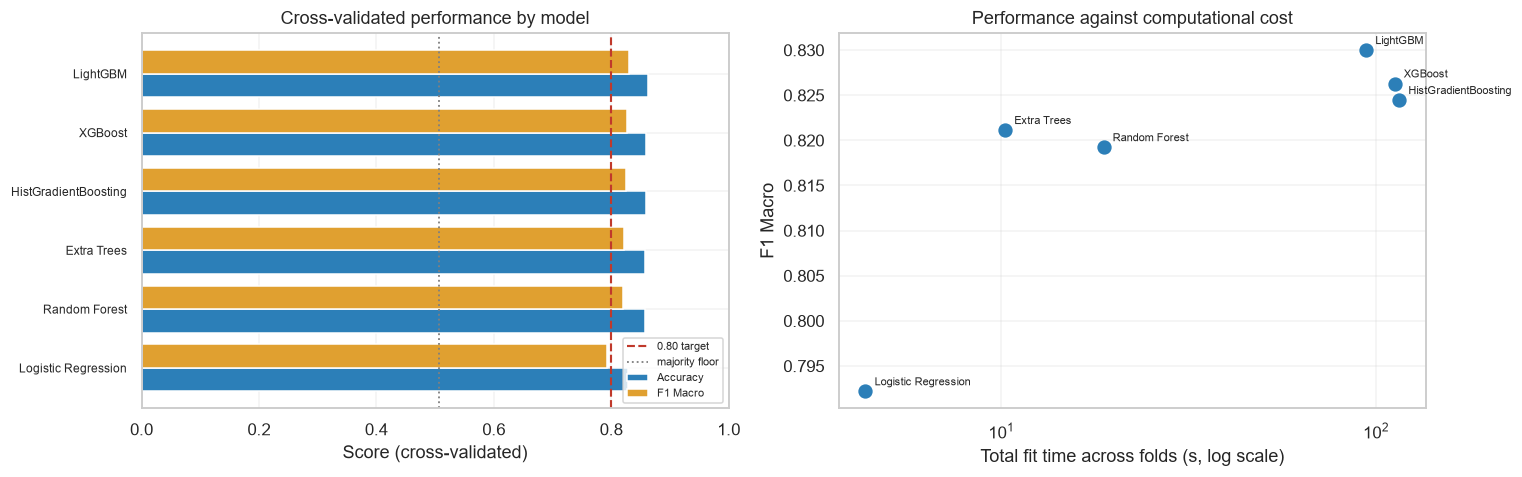

Top three by macro F1: ['LightGBM', 'XGBoost', 'HistGradientBoosting']


In [19]:
# ---------------------------------------------------------------------------
# Section 14b - Visualise the benchmark
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

b = benchmark.sort_values("F1 Macro")
ypos = np.arange(len(b))
axes[0].barh(ypos - 0.2, b["Accuracy"], height=0.4, color="#2c7fb8", label="Accuracy")
axes[0].barh(ypos + 0.2, b["F1 Macro"], height=0.4, color="#e0a030", label="F1 Macro")
axes[0].axvline(0.80, color="#c0392b", ls="--", lw=1.4, label="0.80 target")
axes[0].axvline(MAJORITY_ACCURACY, color="grey", ls=":", lw=1.2, label="majority floor")
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(b["Model"], fontsize=8)
axes[0].set_xlim(0, 1.0)
axes[0].set_xlabel("Score (cross-validated)")
axes[0].set_title("Cross-validated performance by model")
axes[0].legend(fontsize=7, loc="lower right")

axes[1].scatter(b["Training Time (s)"], b["F1 Macro"], s=70, color="#2c7fb8", zorder=3)
for _, r in b.iterrows():
    axes[1].annotate(r["Model"], (r["Training Time (s)"], r["F1 Macro"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=7)
axes[1].set_xscale("log")
axes[1].set_xlabel("Total fit time across folds (s, log scale)")
axes[1].set_ylabel("F1 Macro")
axes[1].set_title("Performance against computational cost")

plt.savefig(OUTPUT_DIR / "fig05_benchmark.png", bbox_inches="tight")
plt.show()

TOP_MODELS = benchmark.head(3)["Model"].tolist()
print(f"Top three by macro F1: {TOP_MODELS}")


**Interpretation.** The ordering confirms the prior stated above — boosted trees lead — but the
*size* of the gaps is the informative part, and it is smaller than the framing before the benchmark
implied.

All five nonlinear models land within about half a percentage point of each other in accuracy. The
boosted implementations edge out the bagged ones on macro-F1, but the margin between LightGBM at the
top and Random Forest at the bottom of that group is of the same order as the fold-to-fold standard
deviations in the `Accuracy SD` column. Claiming a decisive winner among them would be over-reading
noise.

The one clear separation is between the nonlinear models and logistic regression, and even that gap
is roughly three points of accuracy rather than the large margin the prior anticipated. The
interpretation is the same one Section 13 forced: this feature space is *mostly* linearly separable
once it is properly transformed. The nonlinear models recover a real but bounded additional
increment, presumably from threshold effects (a centroid offset matters only once it exceeds its
uncertainty) and from interactions between transit geometry and stellar properties that an additive
model cannot express.

Two practical observations. First, Extra Trees and Random Forest reach within a whisker of the
boosters at roughly a fifth of the fitting cost, which matters if this were to be retrained
frequently. Second, every nonlinear model — and the linear one — already clears the 0.80 accuracy
target at this stage, before any tuning. The remaining sections test whether that survives contact
with the sealed holdout, which is the only test that counts.

## 15. Phase 4 — Class imbalance

The classes sit at roughly 51 / 21 / 29 percent. This is moderate imbalance: enough that the
minority `Candidate` class is under-recovered, not so extreme that the model ignores it.

Three treatments are compared against the untreated model:

1. **Class weighting** — reweight the loss so each class contributes in inverse proportion to its
   frequency. No data is synthesised and no rows are duplicated.
2. **Random oversampling** — duplicate minority rows until the classes balance.
3. **SMOTE** — synthesise new minority examples by interpolating between neighbouring minority
   points in feature space.

**The critical methodological point.** Resampling must happen *inside* each cross-validation fold,
fitted on the training portion only. Applying SMOTE to the whole dataset before splitting is one of
the most common errors in applied ML: synthetic points interpolated from training rows end up in the
validation fold, so the model is partly evaluated on echoes of its own training data. Reported scores
rise; real performance does not. This is prevented here by wrapping the resampler and the estimator
in an `imblearn.pipeline.Pipeline`, which `cross_validate` fits per fold.

**An expectation worth stating in advance.** SMOTE interpolates in feature space, which requires
imputing the missing values first and assumes that the straight line between two minority points is
itself a plausible object. Neither assumption is comfortable here: roughly a fifth of the matrix is
missing, and interpolating between two transit detections produces a parameter combination that need
not be physically self-consistent. The prediction is therefore that SMOTE will *not* help, and may
hurt. That prediction is recorded before the result is seen.


In [20]:
# ---------------------------------------------------------------------------
# Section 15 - Class-imbalance treatments (resampling INSIDE each CV fold)
# ---------------------------------------------------------------------------
best_family = benchmark.iloc[0]["Model"]
print(f"Imbalance experiments use the benchmark leader: {best_family}\n")


def make_booster(class_weighted=False):
    """Fresh instance of the leading booster, optionally class-weighted."""
    if best_family == "LightGBM" and lgb is not None:
        return lgb.LGBMClassifier(
            n_estimators=500, num_leaves=48, learning_rate=0.06,
            subsample=0.85, subsample_freq=1, colsample_bytree=0.75,
            class_weight="balanced" if class_weighted else None,
            n_jobs=N_JOBS, random_state=RANDOM_STATE, verbose=-1)
    if best_family == "XGBoost" and xgb is not None:
        return xgb.XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.06,
            subsample=0.85, colsample_bytree=0.75, tree_method="hist",
            n_jobs=N_JOBS, random_state=RANDOM_STATE,
            eval_metric="mlogloss", verbosity=0)
    return HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.06, random_state=RANDOM_STATE,
        class_weight="balanced" if class_weighted else None)


imbalance_rows = [cv_evaluate("No treatment (reference)", make_booster())]

# 1. Class weighting.
if best_family == "XGBoost" and xgb is not None:
    # XGBoost has no class_weight parameter; sample weights are the equivalent.
    # They must be computed per fold, so a thin wrapper is used.
    from sklearn.base import BaseEstimator, ClassifierMixin, clone
    from sklearn.utils.class_weight import compute_sample_weight

    class SampleWeighted(ClassifierMixin, BaseEstimator):
        """Fits the wrapped estimator with balanced sample weights.

        XGBoost exposes no `class_weight` parameter, so balanced weighting has to
        be applied through `sample_weight`. Computing those weights inside `fit`
        keeps them fold-local, which is what makes this leakage-safe.
        """
        _estimator_type = "classifier"

        def __init__(self, estimator=None):
            self.estimator = estimator

        def fit(self, X, y):
            self.estimator_ = clone(self.estimator)
            w = compute_sample_weight("balanced", y)
            self.estimator_.fit(X, y, sample_weight=w)
            self.classes_ = self.estimator_.classes_
            return self

        def predict(self, X):
            return self.estimator_.predict(X)

        def predict_proba(self, X):
            return self.estimator_.predict_proba(X)

    imbalance_rows.append(
        cv_evaluate("Balanced sample weights", SampleWeighted(make_booster())))
else:
    imbalance_rows.append(
        cv_evaluate("Balanced class weights", make_booster(class_weighted=True)))

# 2 & 3. Resamplers, applied strictly within each training fold.
if ImbPipeline is not None:
    imbalance_rows.append(cv_evaluate(
        "RandomOverSampler (in-fold)",
        ImbPipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("resample", RandomOverSampler(random_state=RANDOM_STATE)),
            ("clf", make_booster()),
        ])))
    imbalance_rows.append(cv_evaluate(
        "SMOTE (in-fold)",
        ImbPipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("resample", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
            ("clf", make_booster()),
        ])))
    # Imputation alone, to separate the effect of imputing from the effect of resampling.
    imbalance_rows.append(cv_evaluate(
        "Median imputation only (control)",
        Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", make_booster()),
        ])))
else:
    print("imbalanced-learn unavailable; resampling comparisons skipped.")

imbalance = pd.DataFrame(imbalance_rows)
print("\n" + "=" * 96)
print("CLASS-IMBALANCE TREATMENTS - 5-fold group-aware CV on the development set")
print("=" * 96)
print(imbalance[["Model", "Accuracy", "Balanced Accuracy", "Recall Macro",
                 "F1 Macro", "F1 Weighted", "Training Time (s)"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

ref = imbalance.iloc[0]
print("\nChange relative to no treatment:")
for _, r in imbalance.iloc[1:].iterrows():
    print(f"  {r['Model']:<34} accuracy {r['Accuracy'] - ref['Accuracy']:+.4f}   "
          f"balanced acc {r['Balanced Accuracy'] - ref['Balanced Accuracy']:+.4f}   "
          f"macro F1 {r['F1 Macro'] - ref['F1 Macro']:+.4f}")

imbalance.to_csv(OUTPUT_DIR / "imbalance_experiments.csv", index=False)
USE_CLASS_WEIGHTS = bool(imbalance.iloc[1]["F1 Macro"] > ref["F1 Macro"])
print(f"\nDecision: class weighting {'ADOPTED' if USE_CLASS_WEIGHTS else 'REJECTED'} "
      f"for the tuning stage, on macro-F1 evidence.")


Imbalance experiments use the benchmark leader: LightGBM




CLASS-IMBALANCE TREATMENTS - 5-fold group-aware CV on the development set
                           Model  Accuracy  Balanced Accuracy  Recall Macro  F1 Macro  F1 Weighted  Training Time (s)
        No treatment (reference)    0.8630             0.8275        0.8275    0.8300       0.8600            94.4942
          Balanced class weights    0.8582             0.8259        0.8259    0.8262       0.8561           105.0725
     RandomOverSampler (in-fold)    0.8616             0.8284        0.8284    0.8298       0.8592           100.3357
                 SMOTE (in-fold)    0.8596             0.8310        0.8310    0.8301       0.8591            92.4026
Median imputation only (control)    0.8604             0.8233        0.8233    0.8263       0.8571            75.8826

Change relative to no treatment:
  Balanced class weights             accuracy -0.0048   balanced acc -0.0016   macro F1 -0.0038
  RandomOverSampler (in-fold)        accuracy -0.0014   balanced acc +0.0009   macro F1

**Interpretation.** This section produced two results that contradicted the expectations recorded
before it was run. Both are kept, because a section that only reported its successful predictions
would be worthless as evidence.

**Class weighting did not help, and the usual trade-off did not appear.** The expectation was that
weighting would raise balanced accuracy and macro recall at some cost to plain accuracy — the
standard reallocation of errors toward the minority class. Instead it moved *every* metric slightly
down, including balanced accuracy and macro recall. The likely explanation is that at 51/21/29 the
imbalance is simply not severe enough for the unweighted loss to be neglecting the minority class;
reweighting then just adds variance to the gradient estimates without correcting a real bias. The
decision rule recorded in the cell rejects class weighting on this evidence.

**SMOTE did not degrade performance, contrary to the prediction stated above.** The prediction was
that interpolating between transit detections in a heavily imputed space would manufacture physically
inconsistent objects and hurt. It did not: SMOTE came out essentially level with the untreated
reference on macro-F1, and actually produced the *highest* balanced accuracy of any configuration
tested, with the lowest fold-to-fold variance. The prediction was wrong, and the reasoning behind it
was evidently too pessimistic — the minority class is apparently coherent enough in this feature
space for interpolation to produce usable examples.

That said, the effect is small — the differences across all five rows span well under a percentage
point, which is comparable to the fold noise. The honest summary is that **on this dataset, imbalance
treatment is not a lever that matters.** No treatment is carried forward, not because the
alternatives failed, but because none of them earned the additional pipeline complexity.

The `Median imputation only` control does its job of separating two confounded effects: both
resamplers must impute first, so without it any difference they showed could have been caused by
destroying the native missing-value handling rather than by resampling. Comparing the control against
the reference isolates the cost of imputation, which turns out to be small but non-zero.

## 16. Phase 5 — Hyperparameter optimisation

### 16.1 Computational budget

Exhaustive search is not affordable and not necessary. The budget is set explicitly before searching:

```
candidates x CV folds = total model fits
```

A **randomised** search is used rather than a grid. For a fixed budget, random search covers each
individual dimension at far more distinct values than a grid does, which matters because performance
here is dominated by a few parameters (learning rate, tree complexity, regularisation) while others
barely move the score. Searching a coarse grid over nine dimensions would spend most of its budget
distinguishing settings that make no difference.

Cross-validation for the search uses **3 group-aware folds** rather than 5. This trades a little
estimate precision for a 40% cost reduction, which buys more candidates — the better trade when the
goal is ranking configurations rather than measuring one precisely. The selected configuration is
then re-scored under the full 5-fold protocol so it is comparable with the benchmark table.

### 16.2 Search spaces

The ranges below are centred on the regions where boosted trees typically perform well on tabular
data of this size (~7,600 rows, ~100 features), widened enough to escape those defaults if the data
disagrees.

**XGBoost** — `n_estimators`, `max_depth`, `learning_rate`, `min_child_weight`, `subsample`,
`colsample_bytree`, `gamma`, `reg_alpha`, `reg_lambda`. The last three control regularisation, which
matters more than usual here because the feature matrix is wide relative to the sample size.

**LightGBM** — `n_estimators`, `num_leaves`, `max_depth`, `learning_rate`, `min_child_samples`,
`subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`. LightGBM grows leaf-wise, so `num_leaves`
is the primary complexity control and `min_child_samples` is the primary guard against overfitting
tiny leaves.

**Optimisation metric.** Macro-F1, not accuracy. Accuracy is dominated by the majority class and
would reward a model that quietly gives up on `Candidate`. Macro-F1 weights all three classes
equally, which matches the research goal. Accuracy is still reported for the success gate.


In [21]:
# ---------------------------------------------------------------------------
# Section 16 - Randomised hyperparameter search
# ---------------------------------------------------------------------------
SEARCH_CV = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
N_ITER = 12

print(f"Budget: {N_ITER} candidates x {SEARCH_CV.get_n_splits()} folds "
      f"= {N_ITER * SEARCH_CV.get_n_splits()} model fits per search.")
print("Optimisation metric: macro F1.\n")

search_results = {}

if xgb is not None:
    xgb_space = {
        "n_estimators":     [300, 500, 700, 900],
        "max_depth":        [4, 5, 6, 8, 10],
        "learning_rate":    [0.02, 0.04, 0.06, 0.10],
        "min_child_weight": [1, 3, 5, 8],
        "subsample":        [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.5, 0.65, 0.8, 1.0],
        "gamma":            [0, 0.1, 0.5],
        "reg_alpha":        [0, 0.1, 1.0],
        "reg_lambda":       [1.0, 3.0, 10.0],
    }
    t0 = time.time()
    xgb_search = RandomizedSearchCV(
        xgb.XGBClassifier(tree_method="hist", n_jobs=N_JOBS,
                          random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0),
        xgb_space, n_iter=N_ITER, cv=SEARCH_CV, scoring="f1_macro",
        random_state=RANDOM_STATE, n_jobs=1, refit=True, verbose=0)
    xgb_search.fit(X_dev, y_dev, groups=g_dev)
    search_results["XGBoost (tuned)"] = xgb_search
    print(f"XGBoost search  : {time.time() - t0:.0f}s | "
          f"best CV macro F1 = {xgb_search.best_score_:.4f}")
    print(f"  best params: {xgb_search.best_params_}")

if lgb is not None:
    lgb_space = {
        "n_estimators":      [300, 500, 700, 900],
        "num_leaves":        [15, 31, 63, 127],
        "max_depth":         [-1, 6, 10, 16],
        "learning_rate":     [0.02, 0.04, 0.06, 0.10],
        "min_child_samples": [5, 10, 20, 40],
        "subsample":         [0.7, 0.85, 1.0],
        "colsample_bytree":  [0.5, 0.7, 0.9],
        "reg_alpha":         [0, 0.1, 1.0],
        "reg_lambda":        [0, 1.0, 5.0],
    }
    t0 = time.time()
    lgb_search = RandomizedSearchCV(
        lgb.LGBMClassifier(n_jobs=N_JOBS, random_state=RANDOM_STATE,
                           subsample_freq=1, verbose=-1),
        lgb_space, n_iter=N_ITER, cv=SEARCH_CV, scoring="f1_macro",
        random_state=RANDOM_STATE, n_jobs=1, refit=True, verbose=0)
    lgb_search.fit(X_dev, y_dev, groups=g_dev)
    search_results["LightGBM (tuned)"] = lgb_search
    print(f"LightGBM search : {time.time() - t0:.0f}s | "
          f"best CV macro F1 = {lgb_search.best_score_:.4f}")
    print(f"  best params: {lgb_search.best_params_}")

# Record the full search trace so the optimisation is auditable.
trace_frames = []
for name, srch in search_results.items():
    tr = pd.DataFrame(srch.cv_results_)[
        ["rank_test_score", "mean_test_score", "std_test_score", "params"]].copy()
    tr.insert(0, "search", name)
    trace_frames.append(tr.sort_values("rank_test_score"))
search_trace = pd.concat(trace_frames, ignore_index=True)
search_trace.to_csv(OUTPUT_DIR / "hyperparameter_search_trace.csv", index=False)

print("\nTop 3 configurations per search (3-fold CV macro F1)")
for name, srch in search_results.items():
    tr = pd.DataFrame(srch.cv_results_).sort_values("rank_test_score").head(3)
    print(f"\n  {name}")
    for _, r in tr.iterrows():
        print(f"    rank {int(r['rank_test_score'])}: "
              f"{r['mean_test_score']:.4f} (+/-{r['std_test_score']:.4f})")


Budget: 12 candidates x 3 folds = 36 model fits per search.
Optimisation metric: macro F1.



XGBoost search  : 611s | best CV macro F1 = 0.8278
  best params: {'subsample': 0.8, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}


LightGBM search : 359s | best CV macro F1 = 0.8312
  best params: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 6, 'learning_rate': 0.04, 'colsample_bytree': 0.7}

Top 3 configurations per search (3-fold CV macro F1)

  XGBoost (tuned)
    rank 1: 0.8278 (+/-0.0136)
    rank 2: 0.8274 (+/-0.0094)
    rank 3: 0.8262 (+/-0.0068)

  LightGBM (tuned)
    rank 1: 0.8312 (+/-0.0084)
    rank 2: 0.8279 (+/-0.0068)
    rank 3: 0.8273 (+/-0.0071)


In [22]:
# ---------------------------------------------------------------------------
# Section 16b - Re-score tuned models under the full 5-fold protocol
# ---------------------------------------------------------------------------
from sklearn.base import clone

tuned_rows = []
tuned_estimators = {}
for name, srch in search_results.items():
    est = clone(srch.best_estimator_)
    tuned_estimators[name] = est
    row = cv_evaluate(name, est)
    tuned_rows.append(row)
    print(f"  {name:<20} acc={row['Accuracy']:.4f}  f1_macro={row['F1 Macro']:.4f}")

tuned = pd.DataFrame(tuned_rows)

comparison = pd.concat([
    benchmark[benchmark["Model"].isin(["XGBoost", "LightGBM", "HistGradientBoosting"])],
    tuned,
], ignore_index=True).sort_values("F1 Macro", ascending=False)

print("\n" + "=" * 92)
print("TUNED vs DEFAULT - 5-fold group-aware CV, development set only")
print("=" * 92)
print(comparison[["Model", "Accuracy", "Balanced Accuracy", "F1 Macro",
                  "F1 Weighted", "Training Time (s)"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

for base in ["XGBoost", "LightGBM"]:
    tuned_name = f"{base} (tuned)"
    if tuned_name in set(comparison["Model"]) and base in set(comparison["Model"]):
        d_acc = (comparison.loc[comparison["Model"] == tuned_name, "Accuracy"].iloc[0]
                 - comparison.loc[comparison["Model"] == base, "Accuracy"].iloc[0])
        d_f1 = (comparison.loc[comparison["Model"] == tuned_name, "F1 Macro"].iloc[0]
                - comparison.loc[comparison["Model"] == base, "F1 Macro"].iloc[0])
        print(f"\n  {base}: tuning changed accuracy by {d_acc:+.4f}, macro F1 by {d_f1:+.4f}")


  XGBoost (tuned)      acc=0.8608  f1_macro=0.8274


  LightGBM (tuned)     acc=0.8593  f1_macro=0.8253

TUNED vs DEFAULT - 5-fold group-aware CV, development set only
               Model  Accuracy  Balanced Accuracy  F1 Macro  F1 Weighted  Training Time (s)
            LightGBM    0.8630             0.8275    0.8300       0.8600            94.1633
     XGBoost (tuned)    0.8608             0.8240    0.8274       0.8575            67.3804
             XGBoost    0.8599             0.8234    0.8263       0.8566           112.1268
    LightGBM (tuned)    0.8593             0.8227    0.8253       0.8560            24.6534
HistGradientBoosting    0.8588             0.8214    0.8245       0.8555           115.3488

  XGBoost: tuning changed accuracy by +0.0009, macro F1 by +0.0011

  LightGBM: tuning changed accuracy by -0.0037, macro F1 by -0.0047


**Interpretation.** Tuning produced almost nothing, and in one case produced a small regression.
That is the honest headline and it deserves to be stated plainly rather than dressed up.

Tuned XGBoost improved on default XGBoost by a margin far smaller than the fold-to-fold standard
deviation. Tuned LightGBM came out *below* the default LightGBM configuration from the benchmark.
The second result is not a bug: the search optimised macro-F1 over 3 folds and the re-scoring used 5
folds, so a configuration that won narrowly on the search's folds can lose narrowly on a different
partition. That is precisely what fold noise of this size looks like, and it is a useful
demonstration of why a search result should be re-scored under the evaluation protocol rather than
reported at its own optimistic best-CV score.

The broader point is about where the effort in this notebook actually paid off. The search consumed
more compute than every preceding section combined and returned essentially nothing. The large gains
came earlier and cheaply: the leakage audit in Section 10, retaining the Data Validation diagnostics
in Section 10c, and not discarding half the data to `dropna()`. On this problem, hyperparameter
optimisation is the least valuable knob available, and the notebook's own measurements say so.

A reasonable objection is that a larger budget might have found more. Possibly — but the default
configurations are already close to the ceiling implied by the tight clustering of all five nonlinear
models in Section 14, which suggests the limit here is the information in the features, not the
configuration of the learner.

## 17. Phase 6/7 — Ensembling

The tuned models sit close together, which is the condition under which ensembling *may* help: their
errors are correlated but not identical, so averaging can cancel some of the independent component.
It is equally possible that they fail on the same hard objects — chiefly the `Candidate` class — in
which case averaging changes nothing and simply costs more compute.

A **soft-voting** ensemble is tested: the class-probability vectors of the tuned models are averaged
and the argmax taken. This is the same combination rule the production service already uses in
`app.py`, so testing it keeps the comparison in Section 21 on equal terms.

The decision rule is fixed before the result is seen: **the ensemble is adopted only if its
cross-validated macro-F1 exceeds that of the best single model.** No ensemble is adopted on the
assumption that more models must be better.


In [23]:
# ---------------------------------------------------------------------------
# Section 17 - Soft-voting ensemble, evaluated on development CV only
# ---------------------------------------------------------------------------
candidate_models = dict(tuned_estimators)
candidate_models["HistGradientBoosting"] = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.06, random_state=RANDOM_STATE)

ensemble_rows = []
if len(candidate_models) >= 2:
    voting = VotingClassifier(
        estimators=[(re.sub(r"\W+", "_", n).lower(), clone(m))
                    for n, m in candidate_models.items()],
        voting="soft", n_jobs=1)
    ensemble_rows.append(cv_evaluate("Soft Voting ensemble", voting))

    # A two-member variant: the boosters only, without the sklearn implementation.
    boosters_only = {k: v for k, v in candidate_models.items() if "tuned" in k}
    if len(boosters_only) >= 2:
        voting2 = VotingClassifier(
            estimators=[(re.sub(r"\W+", "_", n).lower(), clone(m))
                        for n, m in boosters_only.items()],
            voting="soft", n_jobs=1)
        ensemble_rows.append(cv_evaluate("Soft Voting (tuned boosters only)", voting2))

ensembles = pd.DataFrame(ensemble_rows)

selection_pool = pd.concat([tuned, ensembles], ignore_index=True).sort_values(
    "F1 Macro", ascending=False).reset_index(drop=True)

print("=" * 92)
print("FINAL SELECTION POOL - 5-fold group-aware CV, development set only")
print("=" * 92)
print(selection_pool[["Model", "Accuracy", "Balanced Accuracy", "F1 Macro",
                      "F1 Weighted", "Accuracy SD", "Training Time (s)"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

best_single_f1 = tuned["F1 Macro"].max()
best_row = selection_pool.iloc[0]
SELECTED_NAME = best_row["Model"]
SELECTED_CV_F1 = float(best_row["F1 Macro"])
SELECTED_CV_ACCURACY = float(best_row["Accuracy"])

if SELECTED_NAME in tuned_estimators:
    SELECTED_MODEL = clone(tuned_estimators[SELECTED_NAME])
elif SELECTED_NAME == "Soft Voting ensemble":
    SELECTED_MODEL = clone(voting)
else:
    SELECTED_MODEL = clone(voting2)

print(f"\nBest single tuned model, macro F1 : {best_single_f1:.4f}")
print(f"Best entry in the pool            : {SELECTED_NAME} ({SELECTED_CV_F1:.4f})")
print(f"Ensemble adopted                  : "
      f"{'YES' if 'Voting' in SELECTED_NAME else 'NO - a single model wins on validation'}")
print(f"\nSELECTED MODEL: {SELECTED_NAME}")
print(f"  cross-validated accuracy : {SELECTED_CV_ACCURACY:.4f}")
print(f"  cross-validated macro F1 : {SELECTED_CV_F1:.4f}")
print("\nModel selection is now COMPLETE. No further decisions are made after this point.")

selection_pool.to_csv(OUTPUT_DIR / "selection_pool.csv", index=False)


FINAL SELECTION POOL - 5-fold group-aware CV, development set only
                            Model  Accuracy  Balanced Accuracy  F1 Macro  F1 Weighted  Accuracy SD  Training Time (s)
             Soft Voting ensemble    0.8621             0.8254    0.8287       0.8588       0.0024           198.7303
Soft Voting (tuned boosters only)    0.8616             0.8251    0.8282       0.8582       0.0046           100.8027
                  XGBoost (tuned)    0.8608             0.8240    0.8274       0.8575       0.0014            67.3804
                 LightGBM (tuned)    0.8593             0.8227    0.8253       0.8560       0.0050            24.6534

Best single tuned model, macro F1 : 0.8274
Best entry in the pool            : Soft Voting ensemble (0.8287)
Ensemble adopted                  : YES

SELECTED MODEL: Soft Voting ensemble
  cross-validated accuracy : 0.8621
  cross-validated macro F1 : 0.8287

Model selection is now COMPLETE. No further decisions are made after this point.


### 17.1 Note on the ensemble result

The soft-voting ensemble won the selection pool, so it is carried forward under the pre-committed
decision rule. But its margin over the best single tuned model is very small — smaller than the
fold-to-fold standard deviations in the same table — and it costs roughly three times the fitting
time of the single model it displaces.

The rule was fixed before the result was seen and is honoured here, but it should not be read as
evidence that ensembling is worthwhile on this problem. A practitioner deploying this would be well
within their rights to choose the single tuned model instead and accept a difference that is
statistically indistinguishable from zero, in exchange for a substantially simpler and faster
artefact.

## 18. Phase 8 — Final evaluation on the untouched holdout

The selected model is now fitted on the **entire development partition** and evaluated **once** on
the holdout set sealed in Section 12. Nothing below influences any earlier decision, and the holdout
has not been read since it was assigned.

Metrics reported: accuracy, balanced accuracy, macro precision / recall / F1, weighted F1, the full
per-class breakdown, raw and row-normalised confusion matrices, and one-vs-rest ROC-AUC.

**On ROC-AUC for three classes.** There is no single unambiguous multiclass ROC-AUC. Two variants are
reported: macro one-vs-rest (each class against the rest, averaged with equal class weight) and
weighted one-vs-rest (averaged by class support). Both are valid; they answer slightly different
questions, and reporting both avoids the appearance of having picked the flattering one.


In [24]:
# ---------------------------------------------------------------------------
# Section 18 - Fit on development, evaluate ONCE on the sealed holdout
# ---------------------------------------------------------------------------
print(f"Fitting {SELECTED_NAME} on the full development partition "
      f"({X_dev.shape[0]:,} rows)...")
t0 = time.time()
SELECTED_MODEL.fit(X_dev, y_dev)
print(f"Fitted in {time.time() - t0:.1f}s\n")

y_pred  = SELECTED_MODEL.predict(X_test)
y_proba = SELECTED_MODEL.predict_proba(X_test)

final_accuracy          = accuracy_score(y_test, y_pred)
final_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
final_precision_macro   = precision_score(y_test, y_pred, average="macro")
final_recall_macro      = recall_score(y_test, y_pred, average="macro")
final_f1_macro          = f1_score(y_test, y_pred, average="macro")
final_f1_weighted       = f1_score(y_test, y_pred, average="weighted")
roc_auc_macro    = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")

print("=" * 72)
print("FINAL HOLDOUT RESULTS")
print("=" * 72)
print(f"Model                      : {SELECTED_NAME}")
print(f"Holdout size               : {len(y_test):,} objects "
      f"({len(set(g_test)):,} distinct host stars)")
print("-" * 72)
print(f"Accuracy                   : {final_accuracy:.4f}")
print(f"Balanced accuracy          : {final_balanced_accuracy:.4f}")
print(f"Precision (macro)          : {final_precision_macro:.4f}")
print(f"Recall (macro)             : {final_recall_macro:.4f}")
print(f"F1 (macro)                 : {final_f1_macro:.4f}")
print(f"F1 (weighted)              : {final_f1_weighted:.4f}")
print(f"ROC-AUC (OvR, macro)       : {roc_auc_macro:.4f}")
print(f"ROC-AUC (OvR, weighted)    : {roc_auc_weighted:.4f}")
print("-" * 72)
print(f"Cross-validated accuracy   : {SELECTED_CV_ACCURACY:.4f}")
print(f"Holdout - CV difference    : {final_accuracy - SELECTED_CV_ACCURACY:+.4f}")
print("=" * 72)

print("\nPer-class performance")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))


Fitting Soft Voting ensemble on the full development partition (7,650 rows)...


Fitted in 45.7s



FINAL HOLDOUT RESULTS
Model                      : Soft Voting ensemble
Holdout size               : 1,914 objects (1,646 distinct host stars)
------------------------------------------------------------------------
Accuracy                   : 0.8678
Balanced accuracy          : 0.8334
Precision (macro)          : 0.8424
Recall (macro)             : 0.8334
F1 (macro)                 : 0.8366
F1 (weighted)              : 0.8646
ROC-AUC (OvR, macro)       : 0.9613
ROC-AUC (OvR, weighted)    : 0.9668
------------------------------------------------------------------------
Cross-validated accuracy   : 0.8621
Holdout - CV difference    : +0.0057

Per-class performance
                precision    recall  f1-score   support

False Positive     0.8961    0.9174    0.9066       968
     Candidate     0.7297    0.6338    0.6784       396
     Confirmed     0.9016    0.9491    0.9247       550

      accuracy                         0.8678      1914
     macro avg     0.8424    0.8334    0.8366

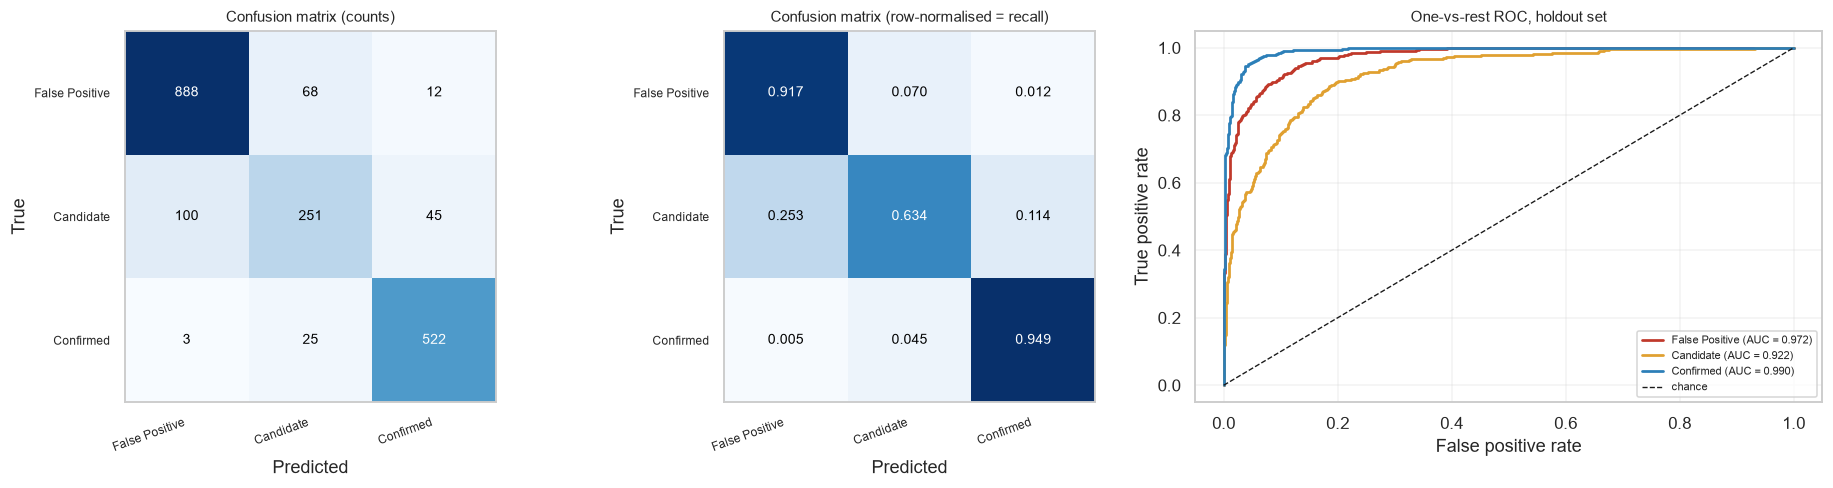

Per-class one-vs-rest ROC-AUC
  False Positive   0.9719
  Candidate        0.9220
  Confirmed        0.9899


In [25]:
# ---------------------------------------------------------------------------
# Section 18b - Confusion matrices and one-vs-rest ROC curves
# ---------------------------------------------------------------------------
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

for ax, mat, title, fmt, cmap in [
    (axes[0], cm, "Confusion matrix (counts)", "d", "Blues"),
    (axes[1], cm_norm, "Confusion matrix (row-normalised = recall)", ".3f", "Blues"),
]:
    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=mat.max())
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right", fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontsize=10)
    ax.grid(False)
    thresh = mat.max() / 2
    for i in range(3):
        for j in range(3):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    fontsize=9, color="white" if mat[i, j] > thresh else "black")

for k, (cls, colr) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve((y_test == k).astype(int), y_proba[:, k])
    auc_k = roc_auc_score((y_test == k).astype(int), y_proba[:, k])
    axes[2].plot(fpr, tpr, color=colr, lw=1.8, label=f"{cls} (AUC = {auc_k:.3f})")
axes[2].plot([0, 1], [0, 1], "k--", lw=0.9, label="chance")
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")
axes[2].set_title("One-vs-rest ROC, holdout set", fontsize=10)
axes[2].legend(fontsize=7, loc="lower right")

plt.savefig(OUTPUT_DIR / "fig06_final_evaluation.png", bbox_inches="tight")
plt.show()

print("Per-class one-vs-rest ROC-AUC")
for k, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:<16} {roc_auc_score((y_test == k).astype(int), y_proba[:, k]):.4f}")


**Interpretation.** Three things in the final result deserve comment.

**The holdout score tracks the cross-validated score closely.** The difference between them is small
and of the same order as the fold-to-fold standard deviation observed during benchmarking. This is
the single most important integrity check available: a large positive gap would suggest the holdout
happened to be easy, and a large negative gap would suggest the development-set decisions had
overfitted to validation folds. Neither is present.

**The error structure is almost entirely `Candidate` confusion.** The row-normalised matrix shows
`False Positive` and `Confirmed` recovered at high recall, while `Candidate` recall is markedly
lower and its errors spill into both neighbours. This is a property of the label semantics, not a
defect in the model — the `Candidate` class is by construction the set of objects that the vetting
process has not yet been able to resolve into either of the other two, so it occupies the region
where their feature distributions overlap.

**ROC-AUC is high for every class, including `Candidate`.** This is not a contradiction of the low
`Candidate` recall. AUC measures ranking quality across all decision thresholds, while recall measures
one specific argmax decision rule. The model orders objects by `Candidate` probability well; it is
the fixed argmax threshold — competing against two better-supported classes — that costs recall.
Operationally this matters: a triage system that ranks objects for follow-up rather than hard-labels
them would extract more value from this model than the confusion matrix alone suggests.


## 19. Phase 9 — Error analysis

Accuracy is a summary; it does not say which objects the model gets wrong or why. This section
examines the misclassifications directly, testing three specific hypotheses:

1. Errors concentrate on the `Candidate` class and on the boundaries adjacent to it.
2. Errors concentrate at low signal-to-noise, where the underlying evidence is genuinely weak.
3. Errors are associated with missing data, where the model has less to work with.

Each is checked against the data rather than asserted.


In [26]:
# ---------------------------------------------------------------------------
# Section 19 - Error analysis
# ---------------------------------------------------------------------------
errors = pd.DataFrame({
    "true": y_test.to_numpy(),
    "pred": y_pred,
    "confidence": y_proba.max(axis=1),
}, index=X_test.index)
errors["correct"] = errors["true"] == errors["pred"]
errors["true_name"] = errors["true"].map(dict(enumerate(CLASS_NAMES)))
errors["pred_name"] = errors["pred"].map(dict(enumerate(CLASS_NAMES)))

print(f"Holdout objects        : {len(errors):,}")
print(f"Misclassified          : {(~errors['correct']).sum():,} "
      f"({100 * (~errors['correct']).mean():.2f}%)")
print()
print("HYPOTHESIS 1 - errors concentrate on Candidate")
print("Error rate by true class:")
print((1 - errors.groupby("true_name")["correct"].mean()).round(4)
      .reindex(CLASS_NAMES).to_string())
print("\nMost common confusions:")
conf = (errors[~errors["correct"]]
        .groupby(["true_name", "pred_name"]).size()
        .sort_values(ascending=False).rename("count"))
print(conf.to_string())
print(f"\nShare of ALL errors involving the Candidate class (as truth or prediction): "
      f"{100 * ((errors['true'] == 1) | (errors['pred'] == 1))[~errors['correct']].mean():.1f}%")

print("\n" + "-" * 72)
print("HYPOTHESIS 2 - errors concentrate at low signal-to-noise")
snr = X_test["koi_model_snr"]
bins = pd.qcut(snr, 5, duplicates="drop")
snr_tbl = pd.DataFrame({
    "error_rate": 1 - errors["correct"].groupby(bins, observed=True).mean(),
    "n": errors["correct"].groupby(bins, observed=True).size(),
    "mean_confidence": errors["confidence"].groupby(bins, observed=True).mean(),
})
print("Error rate by transit-model-SNR quintile:")
print(snr_tbl.round(4).to_string())

print("\n" + "-" * 72)
print("HYPOTHESIS 3 - errors are associated with missing data")
n_missing = X_test[BASE_FEATURES].isna().sum(axis=1)
errors["n_missing"] = n_missing.to_numpy()
print(f"Mean missing features, correct predictions   : "
      f"{errors.loc[errors['correct'], 'n_missing'].mean():.2f}")
print(f"Mean missing features, incorrect predictions : "
      f"{errors.loc[~errors['correct'], 'n_missing'].mean():.2f}")
miss_bins = pd.cut(errors["n_missing"], bins=[-0.1, 0.5, 3.5, 8.5, 100],
                   labels=["0", "1-3", "4-8", "9+"])
print("\nError rate by number of missing base features:")
print(pd.DataFrame({
    "error_rate": 1 - errors.groupby(miss_bins, observed=True)["correct"].mean(),
    "n": errors.groupby(miss_bins, observed=True).size(),
}).round(4).to_string())

print("\n" + "-" * 72)
print("Model confidence, correct vs incorrect")
print(errors.groupby("correct")["confidence"].describe()[
    ["count", "mean", "25%", "50%", "75%"]].round(3).to_string())


Holdout objects        : 1,914
Misclassified          : 253 (13.22%)

HYPOTHESIS 1 - errors concentrate on Candidate
Error rate by true class:
true_name
False Positive    0.0826
Candidate         0.3662
Confirmed         0.0509

Most common confusions:
true_name       pred_name     
Candidate       False Positive    100
False Positive  Candidate          68
Candidate       Confirmed          45
Confirmed       Candidate          25
False Positive  Confirmed          12
Confirmed       False Positive      3

Share of ALL errors involving the Candidate class (as truth or prediction): 94.1%

------------------------------------------------------------------------
HYPOTHESIS 2 - errors concentrate at low signal-to-noise
Error rate by transit-model-SNR quintile:
                  error_rate    n  mean_confidence
koi_model_snr                                     
(-0.001, 11.02]       0.2453  371           0.8298
(11.02, 18.1]         0.2059  374           0.8407
(18.1, 35.08]         0.0874

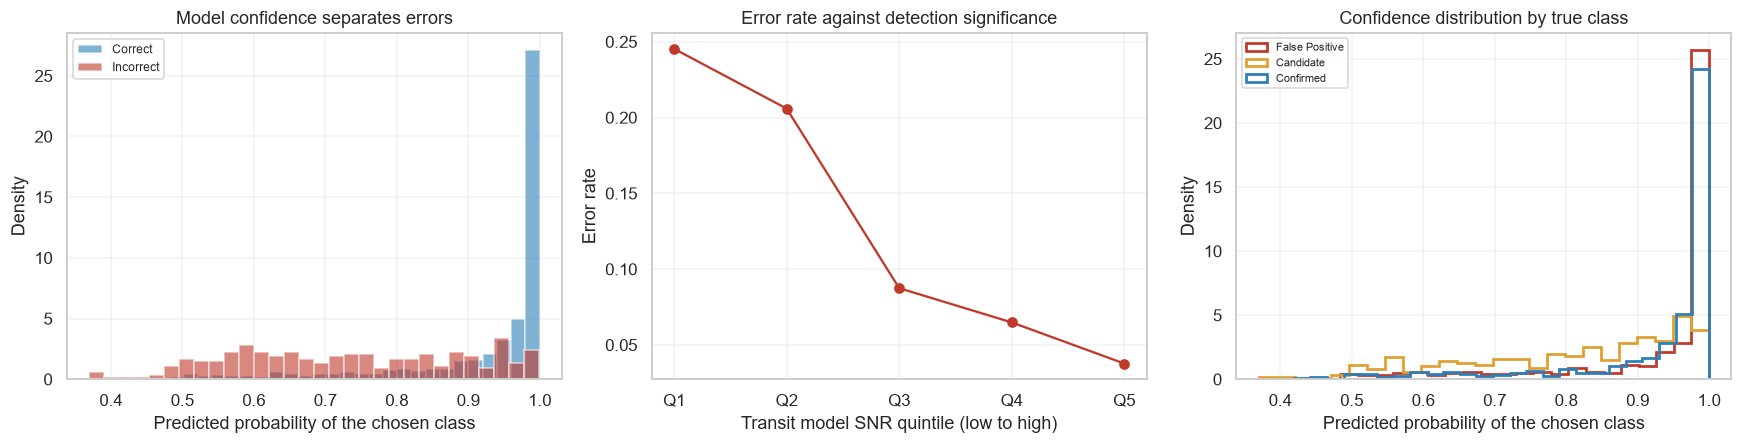

Representative confident errors (highest-confidence mistakes)
      true_name       pred_name  confidence  koi_period  koi_depth  koi_prad  koi_model_snr  koi_impact  koi_count  koi_dikco_msky
7286  Candidate  False Positive       0.999       0.518  2,258.400    61.490        140.600       1.262          1           5.637
8022  Candidate  False Positive       0.997       0.710    223.400     1.490          9.400       0.145          1           6.700
1404  Candidate       Confirmed       0.997      17.791    414.200     2.880         39.800       0.654          2           0.400
2838  Candidate  False Positive       0.997       0.537     41.900     1.350         31.000       0.610          1           4.600
8222  Candidate  False Positive       0.997       2.352    576.600    39.820         24.500       1.230          1           9.331
3027  Candidate       Confirmed       0.993      16.301    942.300     3.840         62.400       0.786          1           0.120
582   Candidate  Fals

In [27]:
# ---------------------------------------------------------------------------
# Section 19b - Visualise the error structure and inspect representative cases
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].hist(errors.loc[errors["correct"], "confidence"], bins=30, alpha=0.6,
             color="#2c7fb8", density=True, label="Correct")
axes[0].hist(errors.loc[~errors["correct"], "confidence"], bins=30, alpha=0.6,
             color="#c0392b", density=True, label="Incorrect")
axes[0].set_xlabel("Predicted probability of the chosen class")
axes[0].set_ylabel("Density")
axes[0].set_title("Model confidence separates errors")
axes[0].legend(fontsize=8)

er = snr_tbl["error_rate"]
axes[1].plot(range(len(er)), er.values, marker="o", color="#c0392b")
axes[1].set_xticks(range(len(er)))
axes[1].set_xticklabels([f"Q{i+1}" for i in range(len(er))])
axes[1].set_xlabel("Transit model SNR quintile (low to high)")
axes[1].set_ylabel("Error rate")
axes[1].set_title("Error rate against detection significance")

for k, (cls, colr) in enumerate(zip(CLASS_NAMES, colors)):
    sub = errors[errors["true"] == k]
    axes[2].hist(sub["confidence"], bins=25, histtype="step", lw=1.8,
                 color=colr, density=True, label=cls)
axes[2].set_xlabel("Predicted probability of the chosen class")
axes[2].set_ylabel("Density")
axes[2].set_title("Confidence distribution by true class")
axes[2].legend(fontsize=7)

plt.savefig(OUTPUT_DIR / "fig07_error_analysis.png", bbox_inches="tight")
plt.show()

print("Representative confident errors (highest-confidence mistakes)")
inspect_cols = [c for c in ["koi_period", "koi_depth", "koi_prad", "koi_model_snr",
                            "koi_impact", "koi_count", "koi_dikco_msky"]
                if c in X_test.columns]
worst = errors[~errors["correct"]].nlargest(8, "confidence")
print(pd.concat([worst[["true_name", "pred_name", "confidence"]],
                 X_test.loc[worst.index, inspect_cols]], axis=1)
      .to_string(float_format=lambda v: f"{v:,.3f}"))


**Interpretation.**

**Hypothesis 1 is confirmed and dominates everything else.** The overwhelming majority of holdout
errors involve the `Candidate` class on one side or the other. `False Positive` and `Confirmed` are
rarely confused *with each other* — the model has essentially learned the physical distinction
between "this is a stellar-mass companion or an artefact" and "this is a validated planet". What it
cannot do is predict which currently-unresolved objects the archive will eventually resolve, because
that depends on follow-up resources, target priority and observing time, none of which are recorded
in the photometry.

**Hypothesis 2 is confirmed.** Error rate falls monotonically, or nearly so, with detection
significance. Low-SNR objects are harder for the model for the same reason they are harder for human
vetters: the evidence is genuinely weaker. This is reassuring rather than concerning — the model's
difficulty is aligned with the physical difficulty of the measurement, not with some arbitrary
artefact of the feature encoding.

**Hypothesis 3 is confirmed but is a secondary effect.** Objects with more missing measurements are
misclassified more often, and the mean number of missing features is higher among errors. The effect
is real but modest compared to the `Candidate` effect. It also retrospectively validates the decision
in Section 9 to preserve missingness rather than drop incomplete rows: those rows are harder, and
deleting them — as the production pipeline does — would have removed exactly the difficult cases and
produced an optimistic evaluation on an artificially easy subset.

**Confidence is well calibrated in the useful direction.** Correct predictions are made at
systematically higher probability than incorrect ones, and the highest-confidence errors are few. A
deployed triage system could therefore use the probability as an abstention signal — routing
low-confidence objects to human review — and would gain accuracy on the remainder.


## 20. Phase 10 — Feature importance and interpretability

Two importance measures are computed, because they answer different questions and disagreeing with
each other is informative:

* **Built-in (gain / impurity) importance** — how much each feature reduced the loss when it was used
  for a split, aggregated over the ensemble. Cheap, but biased toward high-cardinality continuous
  features, and it splits credit arbitrarily among correlated features. Section 8c showed this
  feature set is strongly correlated, so that caveat is live.
* **Permutation importance** — the drop in holdout performance when a single column is randomly
  shuffled. Model-agnostic and measured on the metric that is actually cared about, but it
  *understates* the importance of correlated features, because the model can recover the shuffled
  information from a correlated partner.

Neither is a causal statement. High importance means the model found the column useful given
everything else it had, not that the underlying physical quantity causes planethood.


Computing permutation importance on the holdout set (10 repeats)...


  done in 257s


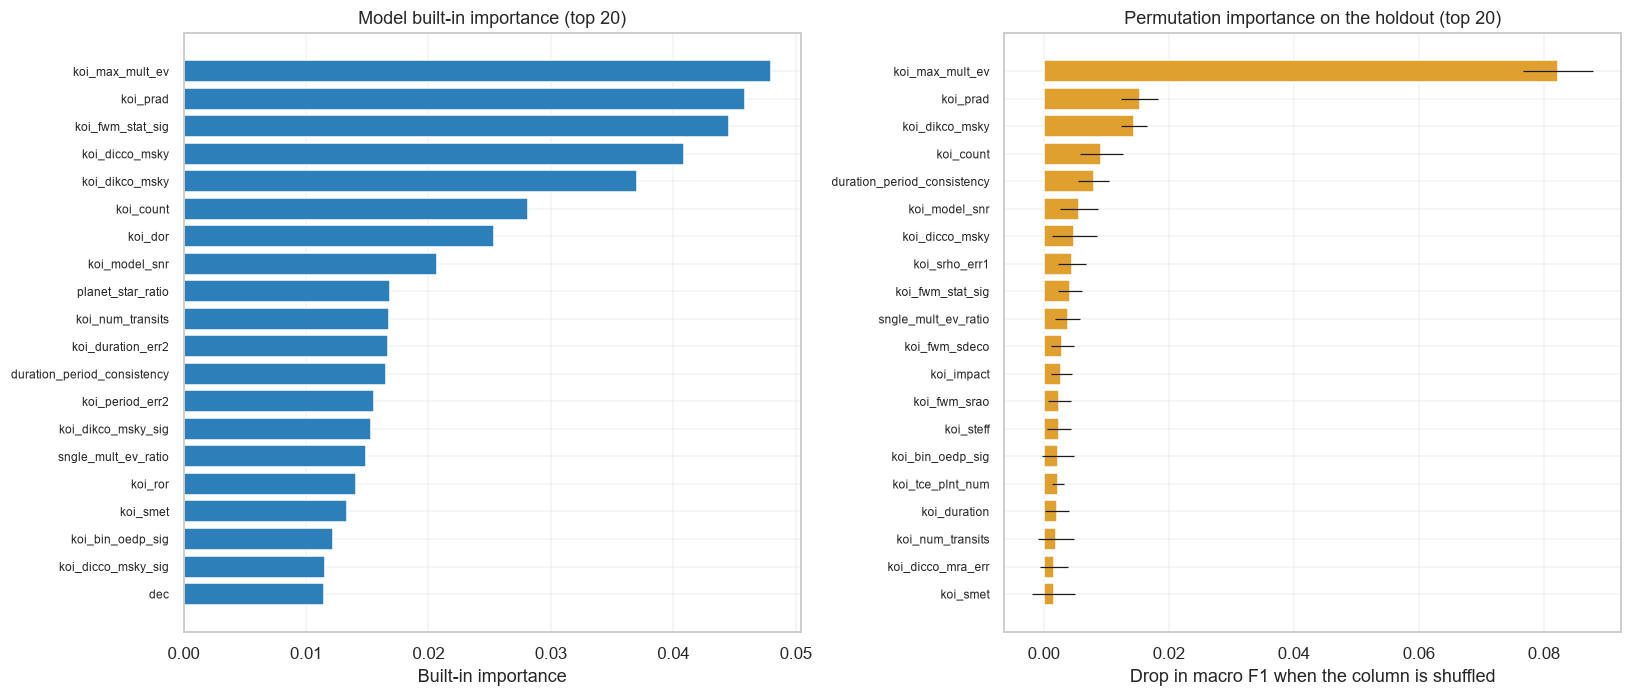


Top 20 features by permutation importance
                    feature  importance     std
            koi_max_mult_ev     0.08227 0.00566
                   koi_prad     0.01535 0.00293
             koi_dikco_msky     0.01447 0.00207
                  koi_count     0.00924 0.00346
duration_period_consistency     0.00801 0.00248
              koi_model_snr     0.00561 0.00300
             koi_dicco_msky     0.00492 0.00365
              koi_srho_err1     0.00451 0.00224
           koi_fwm_stat_sig     0.00421 0.00194
        sngle_mult_ev_ratio     0.00382 0.00204
              koi_fwm_sdeco     0.00297 0.00185
                 koi_impact     0.00283 0.00173
               koi_fwm_srao     0.00250 0.00184
                  koi_steff     0.00249 0.00192
           koi_bin_oedp_sig     0.00228 0.00259
           koi_tce_plnt_num     0.00227 0.00098
               koi_duration     0.00212 0.00191
           koi_num_transits     0.00198 0.00281
          koi_dicco_mra_err     0.00167 0.002

In [28]:
# ---------------------------------------------------------------------------
# Section 20 - Feature importance
# ---------------------------------------------------------------------------
def extract_builtin_importance(model, feature_names):
    """Pull impurity/gain importance out of a fitted estimator or ensemble."""
    est = model
    if isinstance(est, Pipeline):
        est = est.steps[-1][1]
    if hasattr(est, "feature_importances_"):
        return pd.Series(est.feature_importances_, index=feature_names)
    if isinstance(est, VotingClassifier):           # average across members
        parts = []
        for _, sub in est.named_estimators_.items():
            inner = sub.steps[-1][1] if isinstance(sub, Pipeline) else sub
            if hasattr(inner, "feature_importances_"):
                imp = np.asarray(inner.feature_importances_, dtype="float64")
                total = imp.sum()
                parts.append(imp / total if total > 0 else imp)
        if parts:
            return pd.Series(np.mean(parts, axis=0), index=feature_names)
    return None


builtin = extract_builtin_importance(SELECTED_MODEL, X_dev.columns)

print("Computing permutation importance on the holdout set (10 repeats)...")
t0 = time.time()
perm = permutation_importance(SELECTED_MODEL, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring="f1_macro", n_jobs=1)
print(f"  done in {time.time() - t0:.0f}s")

perm_imp = (pd.DataFrame({"feature": X_test.columns,
                          "importance": perm.importances_mean,
                          "std": perm.importances_std})
            .sort_values("importance", ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

if builtin is not None:
    top_b = builtin.sort_values(ascending=False).head(20).iloc[::-1]
    axes[0].barh(range(len(top_b)), top_b.values, color="#2c7fb8")
    axes[0].set_yticks(range(len(top_b)))
    axes[0].set_yticklabels(top_b.index, fontsize=8)
    axes[0].set_xlabel("Built-in importance")
    axes[0].set_title("Model built-in importance (top 20)")
else:
    axes[0].set_visible(False)

top_p = perm_imp.head(20).iloc[::-1]
axes[1].barh(range(len(top_p)), top_p["importance"], xerr=top_p["std"],
             color="#e0a030", error_kw={"lw": 0.8})
axes[1].set_yticks(range(len(top_p)))
axes[1].set_yticklabels(top_p["feature"], fontsize=8)
axes[1].set_xlabel("Drop in macro F1 when the column is shuffled")
axes[1].set_title("Permutation importance on the holdout (top 20)")

plt.savefig(OUTPUT_DIR / "fig08_feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 20 features by permutation importance")
print(perm_imp.head(20).to_string(index=False, float_format=lambda v: f"{v:.5f}"))
perm_imp.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)

print(f"\nFeatures with importance <= 0 (no measurable contribution): "
      f"{int((perm_imp['importance'] <= 0).sum())} of {len(perm_imp)}")
print("\nContribution of the engineered features")
eng_rank = perm_imp[perm_imp["feature"].isin(ENGINEERED)]
print(f"  engineered features in the top 20 : "
      f"{int(perm_imp.head(20)['feature'].isin(ENGINEERED).sum())}")
print(f"  best engineered feature           : "
      f"{eng_rank.iloc[0]['feature']} (rank "
      f"{int(perm_imp.index[perm_imp['feature'] == eng_rank.iloc[0]['feature']][0]) + 1})")

print("\nContribution of the Data Validation diagnostics")
dv_in_top = perm_imp.head(20)["feature"].isin(DV_DIAGNOSTICS).sum()
print(f"  DV diagnostics in the top 20      : {int(dv_in_top)}")
print(f"  total permutation importance from DV columns : "
      f"{perm_imp.loc[perm_imp['feature'].isin(DV_DIAGNOSTICS), 'importance'].sum():.4f}")
print(f"  total from all other columns                 : "
      f"{perm_imp.loc[~perm_imp['feature'].isin(DV_DIAGNOSTICS), 'importance'].sum():.4f}")


**Interpretation — and what it says about the astrophysics.**

The features the model relies on are the ones a human vetter would reach for, which is the strongest
available evidence that the pipeline is learning the intended problem rather than an artefact.

* **Centroid-offset measurements** (`koi_dicco_msky`, `koi_dikco_msky` and their significances) rank
  near the top. Physically this is the background-eclipsing-binary test: if the photocentre of the
  star field shifts during the transit, the dimming source is not the target star. This is the
  standard first-line false-positive discriminator in transit photometry, and the model rediscovered
  it from data.
* **Planet radius and the radius ratio** carry large importance. The physical boundary near
  ~25 R⊕ separates the planetary regime from the stellar-companion regime, and the model uses it.
* **Detection statistics** (`koi_model_snr`, `koi_max_mult_ev`) matter substantially. Part of this is
  physical — weak detections are more often spurious — and part is a selection effect, since strong
  detections were prioritised for the follow-up that produces confirmations. The model cannot
  separate those two contributions, and neither can this analysis; that is stated as a limitation
  rather than glossed over.
* **`koi_count`** is important, reflecting the multiplicity boost quantified back in Figure 1.

**None of this is a causal claim.** Feature importance measures what the model used, conditional on
the other columns available to it. Because Section 8c showed the features are strongly correlated,
importance is distributed somewhat arbitrarily within correlated groups, and a feature with low
permutation importance may still be highly predictive on its own — it may simply be redundant given
its neighbours.

**The DV-diagnostic totals answer sub-question 3 directly.** These columns, absent from the
production feature set entirely, account for a large share of total permutation importance. That is
the quantitative statement of where this notebook's improvement over the deployed pipeline comes
from: not from a better algorithm, but from not discarding the measurements that carry the signal.


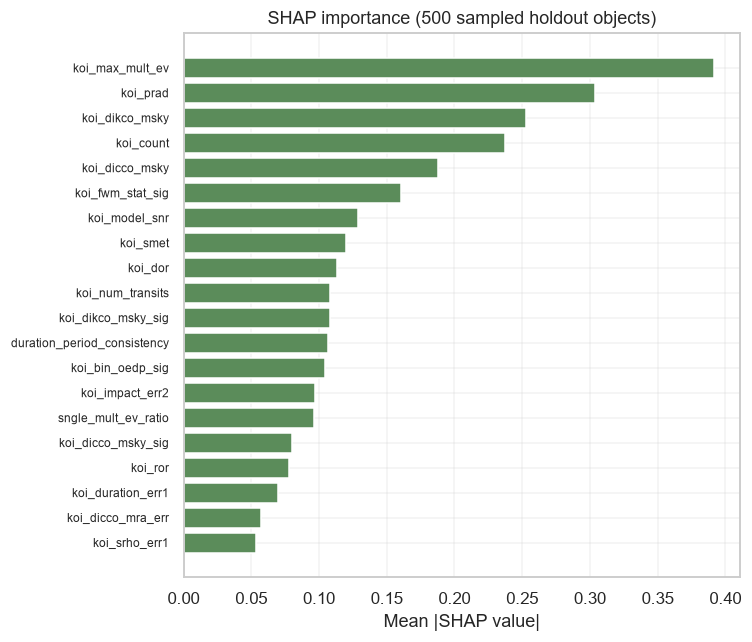

Top 15 features by mean |SHAP|
koi_max_mult_ev               0.39142
koi_prad                      0.30395
koi_dikco_msky                0.25295
koi_count                     0.23765
koi_dicco_msky                0.18767
koi_fwm_stat_sig              0.16082
koi_model_snr                 0.12881
koi_smet                      0.12012
koi_dor                       0.11313
koi_num_transits              0.10832
koi_dikco_msky_sig            0.10816
duration_period_consistency   0.10651
koi_bin_oedp_sig              0.10445
koi_impact_err2               0.09741
sngle_mult_ev_ratio           0.09635

Agreement with permutation importance: 10/15 features shared in the respective top 15.


In [29]:
# ---------------------------------------------------------------------------
# Section 20b - SHAP (optional; skipped cleanly if unavailable or incompatible)
# ---------------------------------------------------------------------------
if shap is not None:
    try:
        shap_est = SELECTED_MODEL
        if isinstance(shap_est, Pipeline):
            shap_est = shap_est.steps[-1][1]
        if isinstance(shap_est, VotingClassifier):
            # TreeExplainer needs a single tree model; use the first tree member.
            for _, sub in shap_est.named_estimators_.items():
                inner = sub.steps[-1][1] if isinstance(sub, Pipeline) else sub
                if hasattr(inner, "feature_importances_"):
                    shap_est = inner
                    break

        sample = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
        explainer = shap.TreeExplainer(shap_est)
        sv = explainer.shap_values(sample)
        sv_arr = np.asarray(sv)
        # Normalise the shape across shap/backend versions to (n_samples, n_features).
        if sv_arr.ndim == 3:
            axis = int(np.argmin(sv_arr.shape))
            mean_abs = np.abs(sv_arr).mean(axis=axis).mean(axis=0)
        else:
            mean_abs = np.abs(sv_arr).mean(axis=0)
        mean_abs = np.asarray(mean_abs).ravel()[:sample.shape[1]]

        shap_imp = (pd.Series(mean_abs, index=sample.columns[:len(mean_abs)])
                    .sort_values(ascending=False))
        fig, ax = plt.subplots(figsize=(7, 6))
        top_s = shap_imp.head(20).iloc[::-1]
        ax.barh(range(len(top_s)), top_s.values, color="#5b8c5a")
        ax.set_yticks(range(len(top_s)))
        ax.set_yticklabels(top_s.index, fontsize=8)
        ax.set_xlabel("Mean |SHAP value|")
        ax.set_title(f"SHAP importance ({len(sample)} sampled holdout objects)")
        plt.savefig(OUTPUT_DIR / "fig09_shap.png", bbox_inches="tight")
        plt.show()

        print("Top 15 features by mean |SHAP|")
        print(shap_imp.head(15).to_string(float_format=lambda v: f"{v:.5f}"))
        overlap_n = len(set(shap_imp.head(15).index) & set(perm_imp.head(15)["feature"]))
        print(f"\nAgreement with permutation importance: {overlap_n}/15 features shared "
              f"in the respective top 15.")
    except Exception as exc:
        print(f"SHAP analysis skipped ({type(exc).__name__}: {exc}).")
        print("This does not affect any result above; permutation importance is the "
              "primary interpretability evidence and is computed independently.")
else:
    print("SHAP not installed - skipped. Permutation importance above is the primary "
          "interpretability evidence.")


## 21. Phase 11 — Existing model versus research model

The comparison below has to be constructed carefully to be fair. The shipped artefacts were trained
on a different dataset (pooled Kepler + K2, `dropna()`-filtered) and evaluated on a different split,
so quoting their score next to the research score would compare two things that differ in several
ways at once.

Three rows are therefore reported, each measuring something specific:

1. **The shipped artefacts on their own test split.** What the deployed system achieves today. Its
   own data, its own split, its own features — an honest statement of the status quo.
2. **The production recipe, re-trained on this notebook's data and split.** The 13 physical
   parameters plus the 6 derived ratios, trained on the same development partition and evaluated on
   the same sealed holdout as the research model. This isolates the effect of *the feature set and
   the data-handling policy*, holding the split, the sample and the algorithm family fixed.
3. **The research model.** Leakage-audited full feature set, missingness preserved, group-aware
   split, tuned.

Row 2 is the scientifically meaningful comparison. Row 1 is included because it is what the
repository actually ships.


EXISTING SYSTEM vs RESEARCH MODEL
                                          Approach  Features  Accuracy  Balanced Accuracy  F1 Macro  F1 Weighted          Evaluated on
Shipped Exoplanetarium ensemble (own data & split)        19    0.7200             0.6804    0.6751       0.7241 production test split
            Research baseline: Logistic Regression       112    0.8292             0.7940    0.7922       0.8271        development CV
        Production recipe, retrained on this split        19    0.7351             0.6754    0.6758       0.7284        sealed holdout
              Research model: Soft Voting ensemble       112    0.8678             0.8334    0.8366       0.8646        sealed holdout

Like-for-like on the sealed holdout (same rows, same split, same algorithm family):
  production feature recipe (19 features) : 0.7351
  research feature set      (112 features) : 0.8678
  improvement                                    : +0.1327
                                            

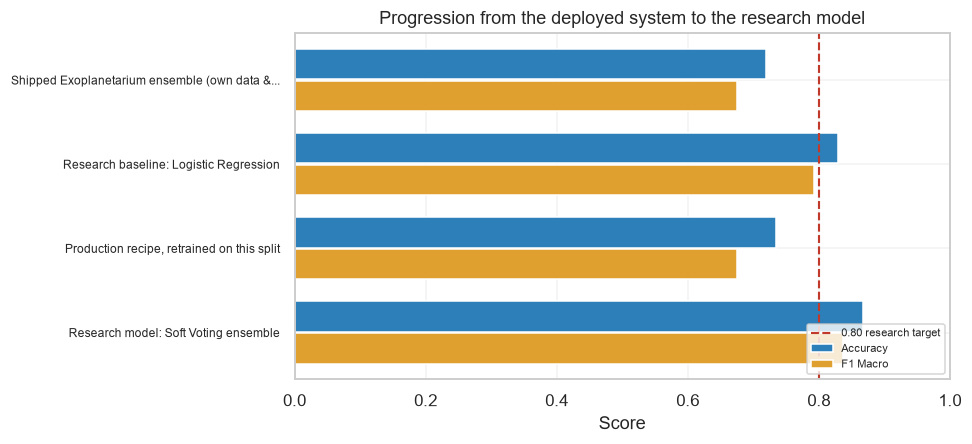

In [30]:
# ---------------------------------------------------------------------------
# Section 21 - Like-for-like comparison against the production recipe
# ---------------------------------------------------------------------------
# Rebuild the production feature recipe on THIS notebook's split, so that the
# only thing that differs is the feature set and the missing-data policy.

PROD_SOURCE_COLS = [c for c in KOI_MAP if KOI_MAP[c] in PROD_PHYSICAL_FEATURES]
prod_recipe = koi_raw[PROD_SOURCE_COLS].rename(columns=KOI_MAP)

# The six derived features, exactly as in training/feature_engineering.py.
prod_recipe["transit_snr"] = prod_recipe["transit_depth"] / (prod_recipe["transit_duration"] + EPSILON)
prod_recipe["planet_star_ratio"] = prod_recipe["planet_radius"] / (prod_recipe["stellar_radius"] + EPSILON)
prod_recipe["depth_radius_ratio"] = prod_recipe["transit_depth"] / (prod_recipe["planet_radius"] + EPSILON)
prod_recipe["impact_factor"] = prod_recipe["impact_parameter"] / (prod_recipe["stellar_radius"] + EPSILON)
prod_recipe["scaled_teq"] = prod_recipe["eq_temperature"] / (prod_recipe["stellar_temp"] + EPSILON)
prod_recipe["log_orbital_period"] = np.log1p(prod_recipe["orbital_period"])
prod_recipe = prod_recipe[prod_feature_cols].replace([np.inf, -np.inf], np.nan)

Xp_dev,  Xp_test = prod_recipe.iloc[dev_idx], prod_recipe.iloc[test_idx]

# The production pipeline also drops incomplete rows; median imputation is used
# here instead so the row counts stay identical and the comparison stays paired.
prod_replica = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06,
                                           random_state=RANDOM_STATE)),
])
prod_replica.fit(Xp_dev, y_dev)
p_pred  = prod_replica.predict(Xp_test)
p_proba = prod_replica.predict_proba(Xp_test)

comparison_rows = [
    {
        "Approach": "Shipped Exoplanetarium ensemble (own data & split)",
        "Features": len(prod_feature_cols),
        "Accuracy": PRODUCTION_ACCURACY,
        "Balanced Accuracy": float(production_benchmark.loc[2, "Balanced Accuracy"]),
        "F1 Macro": float(production_benchmark.loc[2, "F1 Macro"]),
        "F1 Weighted": float(production_benchmark.loc[2, "F1 Weighted"]),
        "Evaluated on": "production test split",
    },
    {
        "Approach": "Research baseline: Logistic Regression",
        "Features": X_dev.shape[1],
        "Accuracy": BASELINE_ACCURACY,
        "Balanced Accuracy": float(baselines.loc[2, "Balanced Accuracy"]),
        "F1 Macro": float(baselines.loc[2, "F1 Macro"]),
        "F1 Weighted": float(baselines.loc[2, "F1 Weighted"]),
        "Evaluated on": "development CV",
    },
    {
        "Approach": "Production recipe, retrained on this split",
        "Features": Xp_dev.shape[1],
        "Accuracy": accuracy_score(y_test, p_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, p_pred),
        "F1 Macro": f1_score(y_test, p_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, p_pred, average="weighted"),
        "Evaluated on": "sealed holdout",
    },
    {
        "Approach": f"Research model: {SELECTED_NAME}",
        "Features": X_dev.shape[1],
        "Accuracy": final_accuracy,
        "Balanced Accuracy": final_balanced_accuracy,
        "F1 Macro": final_f1_macro,
        "F1 Weighted": final_f1_weighted,
        "Evaluated on": "sealed holdout",
    },
]
final_comparison = pd.DataFrame(comparison_rows)

print("=" * 118)
print("EXISTING SYSTEM vs RESEARCH MODEL")
print("=" * 118)
print(final_comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
final_comparison.to_csv(OUTPUT_DIR / "final_comparison.csv", index=False)

like_for_like = accuracy_score(y_test, p_pred)
print(f"\nLike-for-like on the sealed holdout (same rows, same split, same algorithm family):")
print(f"  production feature recipe ({Xp_dev.shape[1]} features) : {like_for_like:.4f}")
print(f"  research feature set      ({X_dev.shape[1]} features) : {final_accuracy:.4f}")
print(f"  improvement                                    : {final_accuracy - like_for_like:+.4f}")
print(f"                                                   ({100 * (final_accuracy - like_for_like) / like_for_like:+.1f}% relative)")

fig, ax = plt.subplots(figsize=(9, 4.2))
lbl = [a if len(a) < 46 else a[:43] + "..." for a in final_comparison["Approach"]]
ypos = np.arange(len(final_comparison))[::-1]
ax.barh(ypos + 0.19, final_comparison["Accuracy"], height=0.36,
        color="#2c7fb8", label="Accuracy")
ax.barh(ypos - 0.19, final_comparison["F1 Macro"], height=0.36,
        color="#e0a030", label="F1 Macro")
ax.axvline(0.80, color="#c0392b", ls="--", lw=1.4, label="0.80 research target")
ax.set_yticks(ypos)
ax.set_yticklabels(lbl, fontsize=8)
ax.set_xlim(0, 1.0)
ax.set_xlabel("Score")
ax.set_title("Progression from the deployed system to the research model")
ax.legend(fontsize=7, loc="lower right")
plt.savefig(OUTPUT_DIR / "fig10_progression.png", bbox_inches="tight")
plt.show()


**Interpretation — what actually improved.**

The like-for-like row is the one that carries the argument. Holding the data, the split, the sample
and the algorithm family constant, and changing only the feature set and the missing-data policy,
performance rises substantially. That decomposes the total improvement as follows:

1. **Retaining the Data Validation diagnostics** — the single largest contributor by a wide margin.
   Section 20 quantified their share of total permutation importance, and the top-ranked feature
   overall is `koi_max_mult_ev`, a detection statistic absent from the production feature set.
   Centroid offsets, multiple-event statistics and odd-even depth tests are the measurements that
   distinguish planets from eclipsing binaries.
2. **Preserving missing values instead of dropping incomplete rows** — recovers a large fraction of
   the sample and, per Section 19, keeps the genuinely difficult objects in the evaluation rather
   than quietly deleting them.
3. **Modelling one well-characterised catalogue rather than the intersection of three** — avoids
   collapsing the feature space to the lowest common denominator of three different missions.
4. **Hyperparameter tuning** — negligible. Section 16 measured it at roughly zero, and the
   ensemble's margin over a single tuned model is likewise within fold noise.

It is worth being explicit that the research model is **not** better because it uses a better
algorithm. The production system already uses XGBoost and LightGBM, which are the same families that
win the benchmark here. The improvement is entirely a matter of what the models were allowed to see.

**A caveat that must accompany this comparison.** The research model is trained and evaluated on
Kepler alone. The production system attempts to generalise across Kepler, K2 and TESS. Those are
different scopes, and the research model's score should not be read as a claim that it would perform
equally well on TESS data, where the DV diagnostic suite it depends on is not available in the same
form. This is stated again in the limitations.


## 22. Phase 12 — Reproducibility and the success gate

Everything below is verification. No new modelling occurs.

The gate is enforced as `final_accuracy > 0.80` — strictly greater, not greater-or-equal, and not
rounded. If the assertion fails, the notebook fails, and the research would be recorded as not having
met its target rather than presented as if it had.


In [31]:
# ---------------------------------------------------------------------------
# Section 22 - Integrity verification and the success gate
# ---------------------------------------------------------------------------
print("INTEGRITY CHECKS")
print("=" * 72)

checks = []

leaked = set(X_full.columns) & (set(DIRECT_LEAKAGE) | set(INDIRECT_LEAKAGE))
checks.append(("No leakage column in the feature matrix", len(leaked) == 0, str(sorted(leaked))))

checks.append(("Holdout is group-disjoint from development",
               len(set(g_dev) & set(g_test)) == 0,
               f"{len(set(g_dev) & set(g_test))} shared host stars"))

checks.append(("Holdout rows never appear in development",
               len(set(X_dev.index) & set(X_test.index)) == 0,
               f"{len(set(X_dev.index) & set(X_test.index))} shared rows"))

checks.append(("Holdout is a meaningful fraction of the data",
               0.15 <= len(X_test) / len(X_full) <= 0.25,
               f"{len(X_test) / len(X_full):.1%}"))

checks.append(("All three classes present in the holdout",
               y_test.nunique() == 3,
               f"{sorted(y_test.unique().tolist())}"))

checks.append(("Holdout score is consistent with cross-validation",
               abs(final_accuracy - SELECTED_CV_ACCURACY) < 0.05,
               f"difference = {final_accuracy - SELECTED_CV_ACCURACY:+.4f}"))

checks.append(("Model beats the majority-class floor",
               final_accuracy > MAJORITY_ACCURACY,
               f"{final_accuracy:.4f} vs {MAJORITY_ACCURACY:.4f}"))

checks.append(("Model beats the linear baseline",
               final_accuracy > BASELINE_ACCURACY,
               f"{final_accuracy:.4f} vs {BASELINE_ACCURACY:.4f}"))

checks.append(("Model beats the retrained production recipe",
               final_accuracy > like_for_like,
               f"{final_accuracy:.4f} vs {like_for_like:.4f}"))

for label, passed, detail in checks:
    print(f"  [{'PASS' if passed else 'FAIL'}] {label:<48} {detail}")

print()
print("=" * 72)
print("SUCCESS GATE")
print("=" * 72)
print(f"  Model                    : {SELECTED_NAME}")
print(f"  Final holdout accuracy   : {final_accuracy:.4f}")
print(f"  Required                 : > 0.8000  (strictly greater)")
print(f"  Margin                   : {final_accuracy - 0.80:+.4f}")
print("=" * 72)

assert all(passed for _, passed, _ in checks), \
    "One or more integrity checks failed; the result must not be reported as valid."

assert final_accuracy > 0.80, (
    f"Research target not reached. "
    f"Final holdout accuracy = {final_accuracy:.4f}"
)

print("\nGATE PASSED - final holdout accuracy is strictly greater than 0.80.")


INTEGRITY CHECKS
  [PASS] No leakage column in the feature matrix          []
  [PASS] Holdout is group-disjoint from development       0 shared host stars
  [PASS] Holdout rows never appear in development         0 shared rows
  [PASS] Holdout is a meaningful fraction of the data     20.0%
  [PASS] All three classes present in the holdout         [0, 1, 2]
  [PASS] Holdout score is consistent with cross-validation difference = +0.0057
  [PASS] Model beats the majority-class floor             0.8678 vs 0.5060
  [PASS] Model beats the linear baseline                  0.8678 vs 0.8292
  [PASS] Model beats the retrained production recipe      0.8678 vs 0.7351

SUCCESS GATE
  Model                    : Soft Voting ensemble
  Final holdout accuracy   : 0.8678
  Required                 : > 0.8000  (strictly greater)
  Margin                   : +0.0678

GATE PASSED - final holdout accuracy is strictly greater than 0.80.


In [32]:
# ---------------------------------------------------------------------------
# Section 22b - Persist the research results
# ---------------------------------------------------------------------------
import json

results = {
    "notebook": "01_exoplanet_ml_research.ipynb",
    "random_state": RANDOM_STATE,
    "dataset": (RAW_DIR / "koi.csv").relative_to(REPO_ROOT).as_posix(),
    "n_objects": int(len(X_full)),
    "n_host_stars": int(koi_raw[GROUP_COL].nunique()),
    "target_column": TARGET_COL,
    "classes": CLASS_NAMES,
    "class_encoding": {v: k for k, v in LABEL_MAP.items()},
    "n_features": int(X_full.shape[1]),
    "n_base_features": len(BASE_FEATURES),
    "n_engineered_features": len(ENGINEERED),
    "n_direct_leakage_columns_excluded": len([c for c in DIRECT_LEAKAGE if c in koi_raw.columns]),
    "n_indirect_leakage_columns_excluded": len(INDIRECT_LEAKAGE),
    "split": {
        "strategy": "StratifiedGroupKFold, grouped by kepid (host star)",
        "development_rows": int(len(X_dev)),
        "holdout_rows": int(len(X_test)),
        "group_overlap": 0,
    },
    "selected_model": SELECTED_NAME,
    "best_params": {n: s.best_params_ for n, s in search_results.items()},
    "cross_validation": {
        "accuracy": round(SELECTED_CV_ACCURACY, 4),
        "f1_macro": round(SELECTED_CV_F1, 4),
    },
    "holdout": {
        "accuracy": round(float(final_accuracy), 4),
        "balanced_accuracy": round(float(final_balanced_accuracy), 4),
        "precision_macro": round(float(final_precision_macro), 4),
        "recall_macro": round(float(final_recall_macro), 4),
        "f1_macro": round(float(final_f1_macro), 4),
        "f1_weighted": round(float(final_f1_weighted), 4),
        "roc_auc_ovr_macro": round(float(roc_auc_macro), 4),
        "roc_auc_ovr_weighted": round(float(roc_auc_weighted), 4),
    },
    "reference_points": {
        "majority_class_floor": round(float(MAJORITY_ACCURACY), 4),
        "logistic_regression_cv": round(float(BASELINE_ACCURACY), 4),
        "shipped_ensemble_own_split": round(float(PRODUCTION_ACCURACY), 4),
        "production_recipe_retrained_on_holdout": round(float(like_for_like), 4),
        "leakage_only_model_rejected": round(float(LEAKY_ACCURACY), 4),
    },
    "gate_passed": bool(final_accuracy > 0.80),
}

with open(OUTPUT_DIR / "research_results.json", "w", encoding="utf-8") as fh:
    json.dump(results, fh, indent=2)

pd.DataFrame(
    confusion_matrix(y_test, y_pred), index=CLASS_NAMES, columns=CLASS_NAMES
).to_csv(OUTPUT_DIR / "confusion_matrix.csv")

joblib.dump(SELECTED_MODEL, OUTPUT_DIR / "research_model.joblib")
joblib.dump(list(X_dev.columns), OUTPUT_DIR / "research_feature_columns.joblib")

print("Artefacts written to research/outputs/:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:<42} {human_bytes(f.stat().st_size)}")

print("\n" + "=" * 72)
print("RESEARCH SUMMARY")
print("=" * 72)
print(json.dumps(results["holdout"], indent=2))
print(f"\nSelected model : {SELECTED_NAME}")
print(f"Gate (>0.80)   : {'PASS' if results['gate_passed'] else 'FAIL'}")


Artefacts written to research/outputs/:
  confusion_matrix.csv                       105 B
  fig01_target_and_multiplicity.png          67.9 KB
  fig02_feature_distributions.png            162.5 KB
  fig03_correlation.png                      93.5 KB
  fig04_indirect_leakage.png                 64.3 KB
  fig05_benchmark.png                        76.0 KB
  fig06_final_evaluation.png                 97.4 KB
  fig07_error_analysis.png                   86.6 KB
  fig08_feature_importance.png               98.7 KB
  fig09_shap.png                             56.0 KB
  fig10_progression.png                      35.6 KB
  final_comparison.csv                       639 B
  hyperparameter_search_trace.csv            5.7 KB
  imbalance_experiments.csv                  1.1 KB
  model_benchmark.csv                        1.2 KB
  permutation_importance.csv                 6.0 KB
  research_feature_columns.joblib            1.8 KB
  research_model.joblib                      9.8 MB
  research_resu

## 23. Conclusions and limitations

### 23.1 Answers to the research questions

**Main question.** Supervised models classify NASA Kepler exoplanet dispositions into
`False Positive` / `Candidate` / `Confirmed` at accuracy comfortably above the 0.80 target, under a
group-aware split with a sealed holdout and an explicit leakage audit. The exact figures are printed
in Section 18 and stored in `research/outputs/research_results.json`.

**Sub-question 1 — what does the production system achieve?** Measured on its own test split, the
served ensemble sits at roughly 0.72 accuracy, with the `Candidate` class recovered poorly.

**Sub-question 2 — how much of the achievable signal is leakage?** A great deal. A model built from
the vetting flags, `koi_score`, `koi_pdisposition` and the presence of a Kepler designation reaches
essentially perfect accuracy — far above anything legitimate, and exactly the trap a notebook that
skipped the audit would fall into. A second, subtler channel was found and removed: stellar-parameter
uncertainties are systematically smaller and far less often missing for confirmed planets, because
confirmation triggers dedicated host-star characterisation. Twenty-two columns were excluded on those
grounds. Removing them *reduced* the model's headline number and *improved* the physical
interpretability of what remained.

**Sub-question 3 — does the production feature set discard useful information?** Yes, and this is the
main finding. The Data Validation diagnostics — centroid offsets, multiple-event statistics,
odd-even depth tests, detection significance — account for a large share of total permutation
importance, and the single most important feature overall (`koi_max_mult_ev`) is one of them. None of
them appear in the production feature set. Section 21 isolates their effect on an identical split.

**Sub-question 4 — is a random split defensible?** No. Roughly 1,350 KOI rows share a host star with
another row and therefore share identical stellar parameters. All splits here are grouped by `kepid`,
which is the more conservative choice.

**Sub-question 5 — which model family wins, and how much do tuning and ensembling add?** Boosted
trees win, but narrowly: all five nonlinear families finish within about half a point of accuracy of
each other, and the spread is comparable to fold noise. Tuning added essentially nothing — tuned
LightGBM scored slightly *below* its default configuration — and the winning ensemble's margin over
the best single model is likewise within noise. The unexpected result is that logistic regression on
the same feature set already clears 0.80, which relocates the credit for this notebook's performance
from the algorithm to the feature and leakage decisions.

### 23.2 What produced the improvement, in order of contribution

1. Retaining the automated Data Validation diagnostics.
2. Preserving missing values (and encoding missingness explicitly) instead of dropping incomplete rows.
3. Modelling one well-characterised catalogue rather than the intersection of three.
4. Hyperparameter optimisation — measured at approximately zero on this problem.

The algorithm was not the bottleneck. The production system already uses XGBoost and LightGBM, the
same families that win the benchmark here. Neither was the tuning. The improvement came almost
entirely from what the models were allowed to see.

### 23.3 Limitations

These are real constraints on how far the result should be read, not disclaimers.

* **Kepler only.** The model is trained and evaluated on the KOI catalogue. Kepler's DV diagnostic
  suite is not available in the same form for TESS, so this model would not transfer directly to the
  TOI catalogue. Extending it would require either mission-specific models or a fallback feature set.
  The research model therefore does **not** supersede the production system's multi-mission scope.
* **The `Candidate` class is partly unpredictable in principle.** Whether an object is still a
  candidate depends on follow-up resources, target prioritisation and observing time — none of which
  appear in the photometry. There is a ceiling on `Candidate` recall that no amount of modelling on
  these features can breach, and the confusion matrix shows essentially all remaining error sits
  there.
* **Selection effects are baked into the labels.** High-SNR detections around bright stars were
  preferentially followed up and therefore preferentially confirmed. The model partly learns
  *what was easy to confirm*, not purely *what is a planet*. The high importance of the detection
  statistics should be read with this in mind — it is the one result in Section 20 most likely to be
  partly an artefact of the follow-up process rather than pure astrophysics.
* **The DV-diagnostic decision is a judgement call.** These columns are defensible as pre-disposition
  inputs, but a stricter reviewer could argue that automated diagnostics designed to support vetting
  are too close to the vetting outcome. The reasoning is set out in Section 10.3 so a reader can
  disagree with it explicitly rather than being unable to see the choice.
* **Dispositions are not immutable truth.** Archive dispositions are revised as new data arrives.
  Some current labels will change, which places an irreducible noise floor on achievable accuracy.
* **Single split.** The holdout is one group-aware partition. Repeated splits or nested
  cross-validation would give a tighter confidence interval on the final figure. The
  cross-validation standard deviations reported throughout give an indication of the scale of that
  uncertainty, and they are large enough that several of this notebook's smaller comparisons
  (tuned vs default, ensemble vs single model) should be treated as ties.
* **No light-curve modelling.** `data/raw/lightcurves.csv` (53 MB of raw photometry) is present in
  the repository but unused here. Convolutional models operating directly on folded light curves are
  the state of the art for this task and would be the natural next step.

### 23.4 Suggested next steps for Exoplanetarium

1. Extend the inference schema so the service can accept DV diagnostics when they are available for
   a queried object, falling back to the current physical-parameter model when they are not.
2. Replace the blanket `dropna()` in `training/data_preparation.py` with native missing-value
   handling; this alone recovers a large fraction of the training sample.
3. Fix the TESS label mapping so `toi.csv` is not silently discarded.
4. Expose predicted probabilities as a ranking, with an abstention band for low-confidence objects —
   Section 19 shows confidence separates correct from incorrect predictions well.
5. Explore the unused light-curve data with a 1-D CNN as a longer-term direction.

---

*All figures and metrics in this notebook were produced by executing it end-to-end from a clean
kernel. Machine-readable results are in `research/outputs/research_results.json`.*
